# QC Comparison Across 5 TF Perturb-seq Benchmark Datasets

Loads the `inference_mudata.h5mu` MuData object for each of the 5 benchmark datasets (Engreitz, Gersbach GEM-X v3, Gersbach HTv2, Hon, Huangfu) and produces side-by-side QC comparison figures across the `gene` and `guide` modalities.

**Schema assumptions** (can't be verified without direct HPC access — adjust the resolver helpers below if these are wrong for your data):
- Gene modality (`mdata['gene']`): gene symbols live in `var['symbol']` (matches `--gene_names_key symbol` used throughout the Inference/Eval pipeline). Falls back to `var_names` if not found.
- Guide modality (`mdata['guide']`): per-cell/per-guide binary assignment lives in `layers['guide_assignment']` (confirmed usage in `benchmark_cnmf_comparison.py`). The guide-to-target mapping column is auto-detected by trying `guide_targets`, `gene_name`, `target_name`, `guide_target`, `target_gene_name` in that order.
- Non-targeting guides are labeled `"non-targeting"` in that target column (matches `--guide_annotation_key 'non-targeting'` / `NON_TARGETING_LABEL` in `benchmark_cnmf_comparison.py`).

- Per-library / per-batch grouping (used in Figure 7): auto-detected from `obs` by trying `library_id`, `library`, `batch`, `lane`, `sample`, `sample_id`, `gem_group`, `GEM_group`, `channel`, `10x_lane`, `pool`, `batch_id` in that order (see `LIBRARY_COL_CANDIDATES` / `resolve_library_col`). If none of these match your data, Figure 7 is skipped for that dataset with a printed warning.

If any of these don't hold, the loop below will raise a `KeyError`/print a warning telling you what columns/layers actually exist so you can fix the resolver.

**New in this version** — Figures 6–7 test whether the between-dataset differences in Figures 1–4 are actually just (1) sequencing depth and (2) library complexity in disguise: Figure 6 visualizes/regresses out depth (`log10 UMI`) and a depth-normalized complexity proxy (`log10(genes)/log10(UMI)`, the "novelty score"), and Figure 7 breaks the core QC metrics out per library/batch to see whether a dataset-level pattern is uniform or driven by one library.

**Figure 8** goes a level more basic than Figures 1-7 (and than the cNMF program comparison in `benchmark_cnmf_comparison.ipynb`): it compares raw pseudobulk gene expression across the 5 datasets directly, with no guide/perturbation information used at all, to check whether the underlying transcriptomes look similar before any perturbation-specific analysis is layered on.

**Figure 9** answers the same question as Figure 6 by construction rather than by regression: it downsamples the datasets to (1) the same number of cells and the same number of transcripts per cell, and (2) the same number of cells and the same number of reads per cell, then re-measures the QC metrics on the matched data. Differences that survive matching are not sequencing-depth artefacts.

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import seaborn as sns
import mudata

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
BASE_DIR = "/hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets"
OUT_DIR  = "/hpc/group/gersbachlab/seg95/tf_perturb_seq/src/tf_perturb_seq/gene_program_discovery/benchmark_figures_qc"
os.makedirs(OUT_DIR, exist_ok=True)

# Same palette as benchmark_cnmf_comparison.py
PALETTE = {
    "CC-Perturb":        "#7030a0",
    "GEM-x v3 10xv3 5'": "#00b050",
    "HTv2 10xv3 5'":     "#ff4b3d",
    "HTO 10xv3 5'":      "#00b0f0",
    "10xv3 3'":          "#ebce9a",
}

# One entry per dataset. "palette_key" must match a key in PALETTE above,
# and "dir" matches the dataset paths used in the run_torch_cnmf_apptainer_*.sh scripts.
DATASETS = [
    {
        "display_name": "CC-Perturb (Engreitz)",
        "dir":          "Engreitz_WTC11-benchmark_TF-Perturb-seq",
        "palette_key":  "CC-Perturb",
    },
    {
        "display_name": "GEM-X v3 10xv3 5' (Gersbach)",
        "dir":          "Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3",
        "palette_key":  "GEM-x v3 10xv3 5'",
    },
    {
        "display_name": "HTv2 10xv3 5' (Gersbach)",
        "dir":          "Gersbach_WTC11-benchmark_TF-Perturb-seq_HTv2",
        "palette_key":  "HTv2 10xv3 5'",
    },
    {
        "display_name": "HTO 10xv3 5' (Hon)",
        "dir":          "Hon_WTC11-benchmark_TF-Perturb-seq",
        "palette_key":  "HTO 10xv3 5'",
    },
    {
        "display_name": "10xv3 3' (Huangfu)",
        "dir":          "Huangfu_WTC11-benchmark_TF-Perturb-seq",
        "palette_key":  "10xv3 3'",
    },
]

for ds in DATASETS:
    ds["color"] = PALETTE[ds["palette_key"]]

DATASET_NAMES = [ds["display_name"] for ds in DATASETS]
COLOR_MAP     = {ds["display_name"]: ds["color"] for ds in DATASETS}

NON_TARGETING_LABEL = "non-targeting"

LIBRARY_COL_CANDIDATES = [
    "library_id", "library", "batch", "lane", "sample", "sample_id",
    "gem_group", "GEM_group", "channel", "10x_lane", "pool", "batch_id",
]

In [3]:
def resolve_h5mu_path(ds):
    """Mirror the fallback used in benchmark_cnmf_comparison.py."""
    p = os.path.join(BASE_DIR, ds["dir"], "sceptre", "inference_mudata_cleaned.h5mu")
    if not os.path.exists(p):
        p = os.path.join(BASE_DIR, ds["dir"], "sceptre", "inference_mudata.h5mu")
    if not os.path.exists(p):
        raise FileNotFoundError(
            f"No mudata file found for {ds['display_name']} under "
            f"{os.path.join(BASE_DIR, ds['dir'], 'sceptre')}"
        )
    return p


def resolve_gene_symbol_col(gene_ad):
    for col in ["symbol", "gene_symbol", "gene_name", "SYMBOL"]:
        if col in gene_ad.var.columns:
            return col
    return None  # fall back to var_names


def get_mito_mask(gene_ad):
    symbol_col = resolve_gene_symbol_col(gene_ad)
    symbols = (gene_ad.var[symbol_col].astype(str) if symbol_col
               else pd.Series(gene_ad.var_names.astype(str)))
    return symbols.str.upper().str.startswith("MT-").values


def resolve_guide_target_col(guide_ad):
    candidates = ["guide_targets", "gene_name", "target_name", "guide_target", "target_gene_name"]
    for col in candidates:
        if col in guide_ad.var.columns:
            return col
    raise KeyError(
        f"Could not find a guide-target column in guide_ad.var. Tried {candidates}. "
        f"Available columns: {list(guide_ad.var.columns)}"
    )


def resolve_library_col(ad):
    """Try to find a per-cell library/batch/lane column in ad.obs. Returns the
    column name or None (caller decides how to handle "not found")."""
    for col in LIBRARY_COL_CANDIDATES:
        if col in ad.obs.columns:
            return col
    return None


def get_guide_assignment(guide_ad):
    if "guide_assignment" not in guide_ad.layers:
        raise KeyError(
            f"'guide_assignment' layer not found. Available layers: {list(guide_ad.layers.keys())}"
        )
    assignment = guide_ad.layers["guide_assignment"]
    if sp.issparse(assignment):
        assignment = assignment.toarray()
    return np.asarray(assignment)


def row_sum(X):
    return np.asarray(X.sum(axis=1)).flatten()


def compute_novelty_score(n_genes, total_counts):
    """Depth-normalized library-complexity proxy ("novelty score"):
    log10(genes detected + 1) / log10(UMI + 1). Lower values at a given depth
    indicate a lower-complexity library (more PCR duplication, fewer unique
    transcripts captured per read)."""
    with np.errstate(divide="ignore", invalid="ignore"):
        score = np.log10(n_genes + 1) / np.log10(total_counts + 1)
    score = np.asarray(score, dtype=float)
    score[~np.isfinite(score)] = np.nan
    return score


def ols_fit(y, x_cols):
    """Minimal OLS via lstsq (intercept + x_cols), NaN-safe. Returns
    (coef, fitted, resid, mask) where coef[0] is the intercept and coef[1:]
    line up with x_cols; fitted/resid are full-length arrays with NaN outside
    `mask` (the rows that had finite y and finite x_cols)."""
    y = np.asarray(y, dtype=float)
    x_cols = [np.asarray(c, dtype=float) for c in x_cols]
    mask = np.isfinite(y)
    for c in x_cols:
        mask &= np.isfinite(c)

    X_design = np.column_stack([np.ones(mask.sum())] + [c[mask] for c in x_cols])
    coef, *_ = np.linalg.lstsq(X_design, y[mask], rcond=None)

    X_design_full = np.column_stack([np.ones(len(y))] + x_cols)
    fitted = np.full(len(y), np.nan)
    fitted[mask] = X_design_full[mask] @ coef

    resid = np.full(len(y), np.nan)
    resid[mask] = y[mask] - fitted[mask]

    return coef, fitted, resid, mask


def grouped_bar_row(df, metrics, titles, fname, ylabels=None, figsize_per_panel=(3.2, 4.2)):
    """One subplot per metric, one bar per dataset within each subplot."""
    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_panel[0] * n, figsize_per_panel[1]))
    if n == 1:
        axes = [axes]
    for i, (ax, metric, title) in enumerate(zip(axes, metrics, titles)):
        vals   = df[metric].values
        colors = [COLOR_MAP[d] for d in df.index]
        ax.bar(range(len(df)), vals, color=colors, edgecolor="black", linewidth=0.5)
        ax.set_xticks(range(len(df)))
        ax.set_xticklabels(df.index, rotation=45, ha="right", fontsize=8)
        ax.set_title(title, fontsize=10, fontweight="bold")
        if ylabels is not None:
            ax.set_ylabel(ylabels[i], fontsize=9)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, fname), dpi=300, bbox_inches="tight")
    return fig

## Load datasets & compute summary statistics

Loads one dataset at a time (freeing memory between) rather than holding all 5 MuData objects in memory simultaneously.

In [4]:
CATEGORY_ORDER = ["No guide", "Exactly 1 guide", "Only NT (>=2)", "Only targeting (>=2)", "Mixed"]

gene_qc_records  = []
guide_qc_records = []
category_records = []
gene_umi_by_ds    = {}
guide_umi_by_ds   = {}
tf_counts_by_ds   = {}
cell_level_dfs    = []
pseudobulk_by_ds  = {}

for ds in DATASETS:
    name = ds["display_name"]
    print(f"\n=== Loading {name} ===")
    h5mu_path = resolve_h5mu_path(ds)
    print(f"  {h5mu_path}")
    mdata = mudata.read_h5mu(h5mu_path)

    gene_ad  = mdata["gene"]
    guide_ad = mdata["guide"]
    print(f"  gene: {gene_ad.shape}   guide: {guide_ad.shape}")

    # --- Gene QC ---
    gX           = gene_ad.X
    total_counts = row_sum(gX)
    n_genes      = row_sum(gX > 0)
    mito_mask    = get_mito_mask(gene_ad)
    if mito_mask.sum() > 0:
        mito_counts = row_sum(gX[:, mito_mask])
        with np.errstate(divide="ignore", invalid="ignore"):
            mito_pct = np.where(total_counts > 0, mito_counts / total_counts * 100, 0.0)
    else:
        print("  WARNING: no MT- genes found via symbol matching; mito%% set to NaN")
        mito_pct = np.full(gene_ad.n_obs, np.nan)

    gene_qc_records.append({
        "dataset":       name,
        "n_cells":       gene_ad.n_obs,
        "median_umi":    np.median(total_counts),
        "median_genes":  np.median(n_genes),
        "mean_mito_pct": np.nanmean(mito_pct),
    })
    gene_umi_by_ds[name] = total_counts

    # --- Guide QC ---
    guide_X            = guide_ad.X
    guide_umi_per_cell = row_sum(guide_X)
    guide_umi_by_ds[name] = guide_umi_per_cell

    assignment = get_guide_assignment(guide_ad)
    target_col = resolve_guide_target_col(guide_ad)
    gene_names = guide_ad.var[target_col].astype(str).values
    is_nt      = (gene_names == NON_TARGETING_LABEL)
    print(f"  guide target col: '{target_col}'  ({is_nt.sum()} NT guides / {len(is_nt)} total)")

    n_hits_per_cell = assignment.sum(axis=1)
    nt_hits         = assignment[:, is_nt].sum(axis=1)
    targ_hits       = assignment[:, ~is_nt].sum(axis=1)

    guide_qc_records.append({
        "dataset":                name,
        "median_guide_umi":       np.median(guide_umi_per_cell),
        "mean_guides_per_cell":   float(np.mean(n_hits_per_cell)),
        "frac_cells_with_guide":  float(np.mean(n_hits_per_cell > 0)),
        "median_cells_per_guide": float(np.median(assignment.sum(axis=0))),
    })

    # --- Guide-count category breakdown ---
    cats = np.empty(assignment.shape[0], dtype=object)
    cats[n_hits_per_cell == 0] = "No guide"
    cats[n_hits_per_cell == 1] = "Exactly 1 guide"
    multi = n_hits_per_cell >= 2
    cats[multi & (targ_hits == 0)]                = "Only NT (>=2)"
    cats[multi & (nt_hits == 0)]                   = "Only targeting (>=2)"
    cats[multi & (targ_hits > 0) & (nt_hits > 0)]  = "Mixed"

    cat_frac = pd.Series(cats).value_counts(normalize=True)
    category_records.append({"dataset": name, **{c: cat_frac.get(c, 0.0) for c in CATEGORY_ORDER}})

    # --- Per-cell assigned TF: prefer a targeting guide if any is present ---
    targeting_mask     = (assignment[:, ~is_nt] > 0)
    has_targeting       = targeting_mask.any(axis=1)
    first_targ_idx       = targeting_mask.argmax(axis=1)
    targeting_gene_names = gene_names[~is_nt]

    assigned_tf = np.where(has_targeting, targeting_gene_names[first_targ_idx], NON_TARGETING_LABEL)
    assigned_tf = assigned_tf.astype(object)
    assigned_tf[n_hits_per_cell == 0] = None

    tf_series = pd.Series(assigned_tf)
    tf_only   = tf_series[tf_series.notna() & (tf_series != NON_TARGETING_LABEL)]
    tf_counts_by_ds[name] = tf_only.value_counts()
    print(f"  {len(tf_counts_by_ds[name])} distinct targeting perturbations detected")


    # --- Per-cell record for depth/complexity regression (Fig. 6) & per-library plots (Fig. 7) ---
    complexity = compute_novelty_score(n_genes, total_counts)

    lib_col = resolve_library_col(gene_ad) or resolve_library_col(guide_ad)
    if lib_col is not None:
        lib_obs = gene_ad.obs if lib_col in gene_ad.obs.columns else guide_ad.obs
        library_labels = lib_obs[lib_col].astype(str).values
        print(f"  library column: '{lib_col}' ({pd.Series(library_labels).nunique()} distinct libraries)")
    else:
        library_labels = np.full(gene_ad.n_obs, "(no library column found)", dtype=object)
        print(f"  WARNING: no library/batch column found in obs (tried {LIBRARY_COL_CANDIDATES}); "
              "per-library plots will be skipped for this dataset")

    cell_level_dfs.append(pd.DataFrame({
        "dataset":          name,
        "library":          library_labels,
        "total_counts":     total_counts,
        "log10_umi":        np.log10(total_counts + 1),
        "n_genes":          n_genes,
        "mito_pct":         mito_pct,
        "complexity":       complexity,
        "n_guides":         n_hits_per_cell,
        "guide_umi":        guide_umi_per_cell,
        "log10_guide_umi":  np.log10(guide_umi_per_cell + 1),
        "has_guide":        (n_hits_per_cell > 0).astype(int),
        "category":         cats,
    }))


    # --- Pseudobulk transcriptome (Fig. 8): raw counts summed over ALL cells,
    # independent of guide/perturbation info entirely, for cross-dataset comparison ---
    symbol_col   = resolve_gene_symbol_col(gene_ad)
    gene_symbols = (gene_ad.var[symbol_col].astype(str) if symbol_col
                    else pd.Series(gene_ad.var_names.astype(str))).values
    gene_sum = np.asarray(gX.sum(axis=0)).flatten()
    pseudobulk_by_ds[name] = (
        pd.Series(gene_sum, index=gene_symbols)
          .groupby(level=0).sum()  # collapse duplicate symbols (multi-probe genes)
    )

    del mdata, gene_ad, guide_ad, gX, guide_X, assignment
    gc.collect()

gene_qc_df  = pd.DataFrame(gene_qc_records).set_index("dataset").loc[DATASET_NAMES]
guide_qc_df = pd.DataFrame(guide_qc_records).set_index("dataset").loc[DATASET_NAMES]
category_df = pd.DataFrame(category_records).set_index("dataset").loc[DATASET_NAMES]
cell_level_df = pd.concat(cell_level_dfs, ignore_index=True)

print("\nDone loading all datasets.")


=== Loading CC-Perturb (Engreitz) ===
  /hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets/Engreitz_WTC11-benchmark_TF-Perturb-seq/sceptre/inference_mudata.h5mu
  gene: (79596, 10812)   guide: (79596, 416)
  guide target col: 'gene_name'  (30 NT guides / 416 total)
  60 distinct targeting perturbations detected
  library column: 'batch' (8 distinct libraries)

=== Loading GEM-X v3 10xv3 5' (Gersbach) ===
  /hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets/Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3/sceptre/inference_mudata.h5mu
  gene: (58113, 13761)   guide: (58113, 416)
  guide target col: 'gene_name'  (30 NT guides / 416 total)
  60 distinct targeting perturbations detected
  library column: 'batch' (4 distinct libraries)

=== Loading HTv2 10xv3 5' (Gersbach) ===
  /hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets/Gersbach_WTC11-benchmark_TF-Perturb-seq_HTv2/sceptre/inference_mudata.h5mu
  gene: (110339, 10097)   guide: (110339, 416)
  guide target col: 'gene_name'  (30

In [5]:
gene_qc_df.round(2)

,n_cells,median_umi,median_genes,mean_mito_pct
dataset,,,,
CC-Perturb (Engreitz),79596,9808.0,2834.0,10.68
GEM-X v3 10xv3 5' (Gersbach),58113,29282.0,6803.0,7.81
HTv2 10xv3 5' (Gersbach),110339,790.0,637.0,2.87
HTO 10xv3 5' (Hon),60817,4853.0,2372.0,6.10
10xv3 3' (Huangfu),101939,4392.0,2350.0,8.63


In [6]:
guide_qc_df.round(3)

,median_guide_umi,mean_guides_per_cell,frac_cells_with_guide,median_cells_per_guide
dataset,,,,
CC-Perturb (Engreitz),5.0,0.292,0.213,49.0
GEM-X v3 10xv3 5' (Gersbach),596.0,1.627,0.935,174.0
HTv2 10xv3 5' (Gersbach),61.0,0.934,0.526,114.5
HTO 10xv3 5' (Hon),725.0,1.928,0.995,234.5
10xv3 3' (Huangfu),195.0,1.424,0.930,301.0


In [7]:
category_df.round(3)

,No guide,Exactly 1 guide,Only NT (>=2),Only targeting (>=2),Mixed
dataset,,,,,
CC-Perturb (Engreitz),0.787,0.155,0.000,0.049,0.008
GEM-X v3 10xv3 5' (Gersbach),0.065,0.484,0.004,0.334,0.113
HTv2 10xv3 5' (Gersbach),0.474,0.299,0.002,0.162,0.063
HTO 10xv3 5' (Hon),0.005,0.500,0.002,0.393,0.100
10xv3 3' (Huangfu),0.070,0.607,0.001,0.272,0.051


## Figure 1: Gene-level QC across datasets
Number of cells, median UMI / cell, median genes / cell, mean mito %.

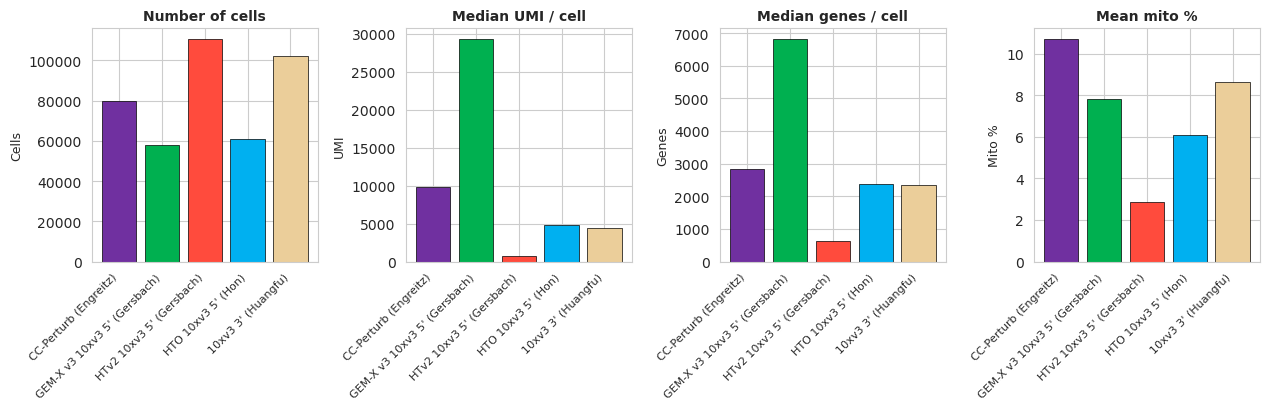

In [8]:
fig1 = grouped_bar_row(
    gene_qc_df,
    metrics=["n_cells", "median_umi", "median_genes", "mean_mito_pct"],
    titles=["Number of cells", "Median UMI / cell", "Median genes / cell", "Mean mito %"],
    ylabels=["Cells", "UMI", "Genes", "Mito %"],
    fname="Q1_gene_qc_barplots.png",
)
plt.show()

## Figure 2: Guide-level QC across datasets
Median guide UMI, mean guides / cell, fraction of cells with a guide, median cells / guide.

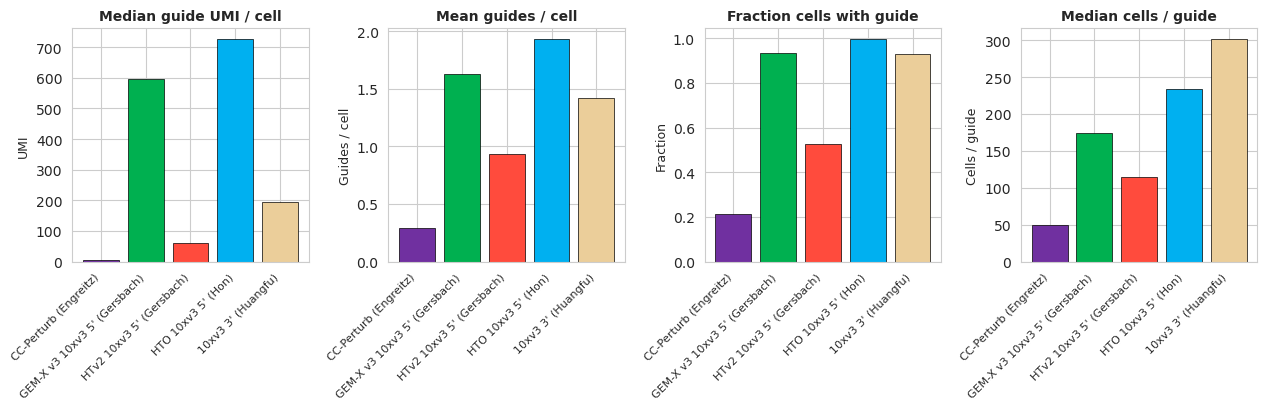

In [9]:
fig2 = grouped_bar_row(
    guide_qc_df,
    metrics=["median_guide_umi", "mean_guides_per_cell", "frac_cells_with_guide", "median_cells_per_guide"],
    titles=["Median guide UMI / cell", "Mean guides / cell", "Fraction cells with guide", "Median cells / guide"],
    ylabels=["UMI", "Guides / cell", "Fraction", "Cells / guide"],
    fname="Q2_guide_qc_barplots.png",
)
plt.show()

## Figure 3: UMI distributions (violin plots)
Gene UMIs / cell and guide UMIs / cell, log10-transformed for readability given heavy-tailed count distributions.

/tmp/ipykernel_2397686/2493163529.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=gene_umi_long, x="dataset", y="log10_umi", palette=COLOR_MAP, ax=axes[0], cut=0)
/tmp/ipykernel_2397686/2493163529.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=guide_umi_long, x="dataset", y="log10_umi", palette=COLOR_MAP, ax=axes[1], cut=0)


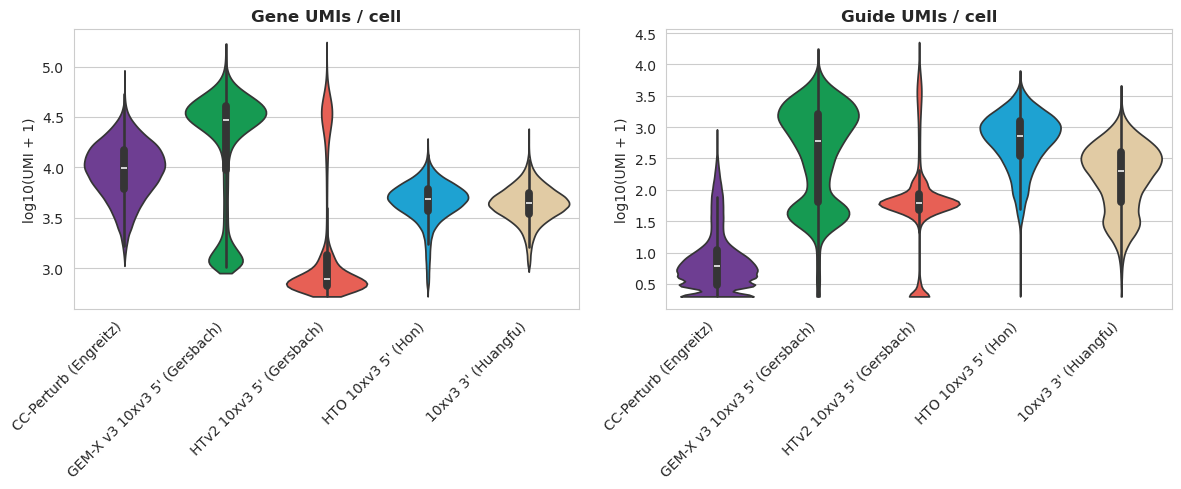

In [10]:
def long_form(dist_dict, value_name):
    frames = []
    for name in DATASET_NAMES:
        frames.append(pd.DataFrame({"dataset": name, value_name: dist_dict[name]}))
    return pd.concat(frames, ignore_index=True)

gene_umi_long  = long_form(gene_umi_by_ds, "umi")
gene_umi_long["log10_umi"] = np.log10(gene_umi_long["umi"] + 1)

guide_umi_long = long_form(guide_umi_by_ds, "umi")
guide_umi_long["log10_umi"] = np.log10(guide_umi_long["umi"] + 1)

fig3, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(data=gene_umi_long, x="dataset", y="log10_umi", palette=COLOR_MAP, ax=axes[0], cut=0)
axes[0].set_title("Gene UMIs / cell", fontweight="bold")
axes[0].set_ylabel("log10(UMI + 1)")
axes[0].set_xlabel(None)
axes[0].tick_params(axis="x", rotation=45)
for lbl in axes[0].get_xticklabels():
    lbl.set_ha("right")

sns.violinplot(data=guide_umi_long, x="dataset", y="log10_umi", palette=COLOR_MAP, ax=axes[1], cut=0)
axes[1].set_title("Guide UMIs / cell", fontweight="bold")
axes[1].set_ylabel("log10(UMI + 1)")
axes[1].set_xlabel(None)
axes[1].tick_params(axis="x", rotation=45)
for lbl in axes[1].get_xticklabels():
    lbl.set_ha("right")

fig3.tight_layout()
fig3.savefig(os.path.join(OUT_DIR, "Q3_umi_violin_plots.png"), dpi=300, bbox_inches="tight")
plt.show()

## Figure 4: Guide assignment categories
Fraction of cells with: no guide, exactly 1 guide, only non-targeting guides (>=2), only targeting guides (>=2), and a mix of NT + targeting guides.

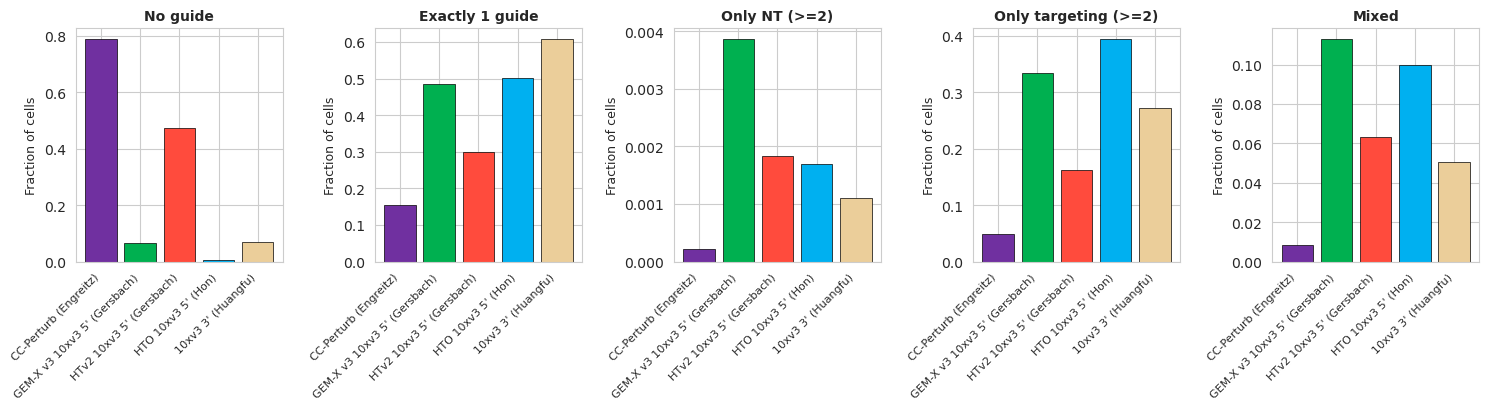

In [11]:
fig4 = grouped_bar_row(
    category_df,
    metrics=CATEGORY_ORDER,
    titles=CATEGORY_ORDER,
    ylabels=["Fraction of cells"] * len(CATEGORY_ORDER),
    fname="Q4_guide_category_barplots.png",
    figsize_per_panel=(3.0, 4.2),
)
plt.show()

## Figure 5: Perturbations remaining vs. cell-count threshold
For each dataset, the number of distinct targeting perturbations (TFs) that have at least N assigned cells, as N increases. A cell is assigned to a TF if it has at least one guide targeting that TF (preferring a targeting guide over non-targeting when a cell has a mix).

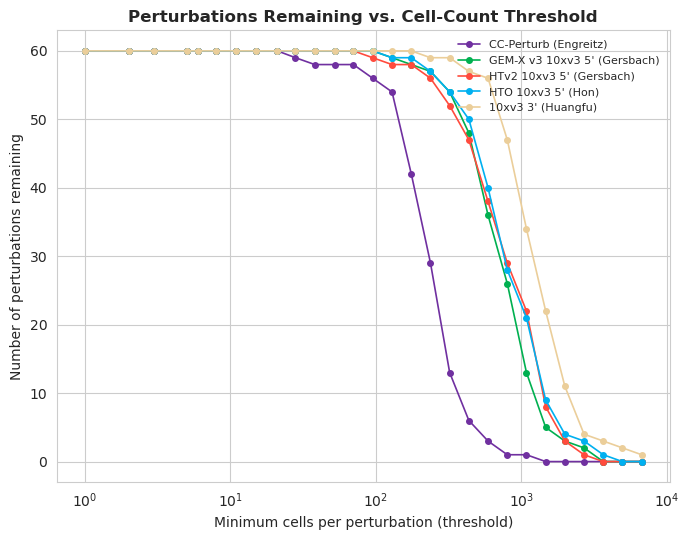

In [12]:
max_cells_seen = max(counts.max() for counts in tf_counts_by_ds.values() if len(counts) > 0)
thresholds = np.unique(np.round(np.geomspace(1, max_cells_seen, 30)).astype(int))

fig5, ax = plt.subplots(figsize=(7, 5.5))
for ds in DATASETS:
    name        = ds["display_name"]
    counts      = tf_counts_by_ds[name].values
    n_remaining = [int((counts >= t).sum()) for t in thresholds]
    ax.plot(thresholds, n_remaining, marker="o", markersize=4, linewidth=1.2,
            color=ds["color"], label=name)

ax.set_xscale("log")
ax.set_xlabel("Minimum cells per perturbation (threshold)")
ax.set_ylabel("Number of perturbations remaining")
ax.set_title("Perturbations Remaining vs. Cell-Count Threshold", fontweight="bold")
ax.legend(frameon=False, fontsize=8, loc="upper right")
fig5.tight_layout()
fig5.savefig(os.path.join(OUT_DIR, "Q5_perturbations_vs_threshold.png"), dpi=300, bbox_inches="tight")
plt.show()

## Figure 6: Sequencing depth & library complexity, per dataset

Addresses the feedback: *differences in (1) sequencing depth and (2) library complexity could explain a lot of the between-dataset differences in Figures 1–4 — can we regress that out (or show it in the plots) to test whether that's true?*

Two per-cell covariates, both computed from the gene modality:
- **Depth** — `log10_umi` = `log10(UMI + 1)`, i.e. the same `total_counts` used in Figure 3.
- **Complexity** — `complexity` = `log10(genes + 1) / log10(UMI + 1)`, the depth-normalized "novelty score" (see `compute_novelty_score`). A lower score at matched depth means fewer unique genes are being recovered per UMI — a hallmark of a lower-complexity library (more PCR duplication / redundant reads).

6a shows the raw per-cell depth-vs-complexity distribution for each dataset; 6b collapses each dataset to its median depth/complexity so the between-dataset separation is easy to read directly.

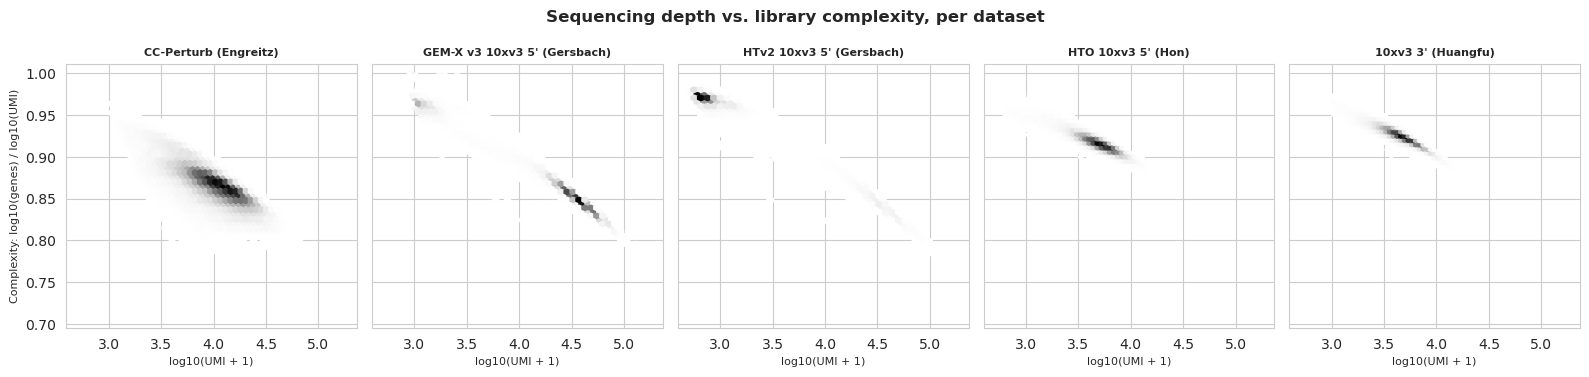

In [13]:
fig_dc, axes = plt.subplots(1, len(DATASET_NAMES), figsize=(3.2 * len(DATASET_NAMES), 3.8),
                             sharex=True, sharey=True)
for ax, name in zip(axes, DATASET_NAMES):
    sub = cell_level_df[cell_level_df["dataset"] == name]
    ax.hexbin(sub["log10_umi"], sub["complexity"], gridsize=40, cmap="Greys", mincnt=1)
    ax.set_title(name, fontsize=8, fontweight="bold")
    ax.set_xlabel("log10(UMI + 1)", fontsize=8)
axes[0].set_ylabel("Complexity: log10(genes) / log10(UMI)", fontsize=8)
fig_dc.suptitle("Sequencing depth vs. library complexity, per dataset", fontweight="bold")
fig_dc.tight_layout()
fig_dc.savefig(os.path.join(OUT_DIR, "Q6a_depth_vs_complexity_landscape.png"), dpi=300, bbox_inches="tight")
plt.show()

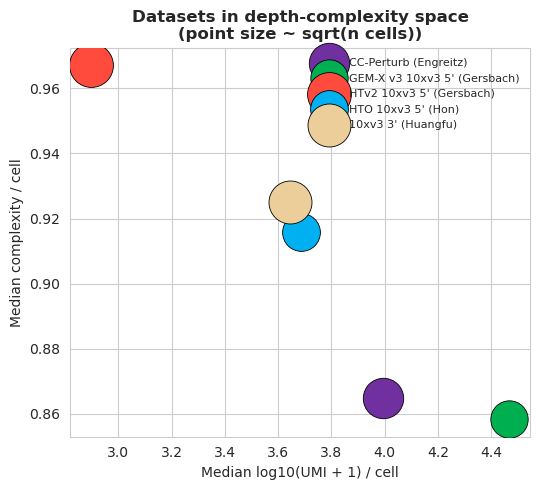

,median_log10_umi,median_complexity,n_cells
dataset,,,
CC-Perturb (Engreitz),3.992,0.865,79596
GEM-X v3 10xv3 5' (Gersbach),4.467,0.858,58113
HTv2 10xv3 5' (Gersbach),2.898,0.967,110339
HTO 10xv3 5' (Hon),3.686,0.916,60817
10xv3 3' (Huangfu),3.643,0.925,101939


In [14]:
depth_complexity_summary = cell_level_df.groupby("dataset").agg(
    median_log10_umi=("log10_umi", "median"),
    median_complexity=("complexity", "median"),
    n_cells=("dataset", "size"),
).loc[DATASET_NAMES]

fig_dc2, ax = plt.subplots(figsize=(5.5, 5))
for name in DATASET_NAMES:
    row = depth_complexity_summary.loc[name]
    ax.scatter(row["median_log10_umi"], row["median_complexity"],
               s=np.sqrt(row["n_cells"]) * 3, color=COLOR_MAP[name],
               edgecolor="black", linewidth=0.6, label=name, zorder=3)
ax.set_xlabel("Median log10(UMI + 1) / cell")
ax.set_ylabel("Median complexity / cell")
ax.set_title("Datasets in depth-complexity space\n(point size ~ sqrt(n cells))", fontweight="bold")
ax.legend(frameon=False, fontsize=8, loc="best")
fig_dc2.tight_layout()
fig_dc2.savefig(os.path.join(OUT_DIR, "Q6b_dataset_depth_complexity_summary.png"), dpi=300, bbox_inches="tight")
plt.show()

depth_complexity_summary.round(3)

### Figure 6c: Depth- and complexity-adjusted comparison

For a few of the metrics compared raw in Figures 1–2 (`mito_pct`, `n_genes`, `log10(guide UMI)`, fraction of cells with a guide assigned), fit one pooled linear model **across all cells from all 5 datasets together**:

`metric ~ log10_umi + complexity`

Dataset is *not* a predictor, so the fitted values reflect only what depth/complexity predict. Each cell's residual (`metric - fitted`) is added back to the pooled grand mean to get an "adjusted" value on the metric's original scale — i.e. what that cell's value would look like if every dataset shared the same average depth & complexity. Averaging the adjusted values within each dataset and comparing to the raw per-dataset average shows whether the between-dataset spread shrinks once depth/complexity are accounted for.

`r2_depth_complexity` is the pooled model's R² (cell-to-cell variance explained by depth+complexity). `frac_between_dataset_var_explained` is the more direct answer to the original question — it's `1 - var(adjusted dataset means) / var(raw dataset means)`, the fraction of the *between-dataset* spread attributable to depth/complexity. Close to 1 → depth/complexity mostly explain the dataset differences for that metric; close to 0 → the differences persist after adjustment (likely a real technical/biological difference beyond depth & complexity).

Caveats: this is a simple linear approximation (no interaction/nonlinear terms), and `has_guide` (0/1) is fit with OLS as a linear-probability-model approximation rather than logistic regression — fine for a descriptive check, not for formal inference.

In [15]:
def depth_complexity_adjust(df, metric_col):
    """OLS: metric ~ log10_umi + complexity, pooled across all cells/datasets.
    Adds '_fitted'/'_resid'/'_adjusted' columns; '_adjusted' = grand_mean + residual."""
    y     = df[metric_col].values.astype(float)
    depth = df["log10_umi"].values.astype(float)
    cplx  = df["complexity"].values.astype(float)
    coef, fitted, resid, mask = ols_fit(y, [depth, cplx])
    grand_mean = np.nanmean(y[mask])
    out = df.copy()
    out["_fitted"]   = fitted
    out["_resid"]    = resid
    out["_adjusted"] = grand_mean + resid
    return out, coef, mask


metrics_to_adjust = {
    "mito_pct":        "Mean mito %",
    "n_genes":         "Mean genes / cell",
    "log10_guide_umi": "Mean log10(guide UMI + 1)",
    "has_guide":       "Fraction cells with guide",
}

raw_records, adj_records, r2_records = [], [], []

for col, label in metrics_to_adjust.items():
    df_adj, coef, mask = depth_complexity_adjust(cell_level_df, col)

    y      = df_adj[col].values.astype(float)
    fitted = df_adj["_fitted"].values
    ss_res = np.nansum((y[mask] - fitted[mask]) ** 2)
    ss_tot = np.nansum((y[mask] - np.nanmean(y[mask])) ** 2)
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    raw_means = df_adj.groupby("dataset")[col].mean().loc[DATASET_NAMES]
    adj_means = df_adj.groupby("dataset")["_adjusted"].mean().loc[DATASET_NAMES]

    raw_var = np.var(raw_means.values, ddof=0)
    adj_var = np.var(adj_means.values, ddof=0)
    frac_explained = 1 - adj_var / raw_var if raw_var > 0 else np.nan

    for name in DATASET_NAMES:
        raw_records.append({"dataset": name, "metric": label, "value": raw_means[name], "kind": "Raw"})
        adj_records.append({"dataset": name, "metric": label, "value": adj_means[name],
                             "kind": "Depth+complexity-adjusted"})

    r2_records.append({
        "metric": label,
        "r2_depth_complexity": r2,
        "depth_coef": coef[1],
        "complexity_coef": coef[2],
        "frac_between_dataset_var_explained": frac_explained,
    })

adjust_plot_df = pd.DataFrame(raw_records + adj_records)
r2_df = pd.DataFrame(r2_records).set_index("metric")
r2_df.round(3)

,r2_depth_complexity,depth_coef,complexity_coef,frac_between_dataset_var_explained
metric,,,,
Mean mito %,0.301,0.203,-49.005,0.575
Mean genes / cell,0.883,5129.231,19964.010,0.795
Mean log10(guide UMI + 1),0.329,2.811,32.114,0.687
Fraction cells with guide,0.276,1.343,15.489,0.799


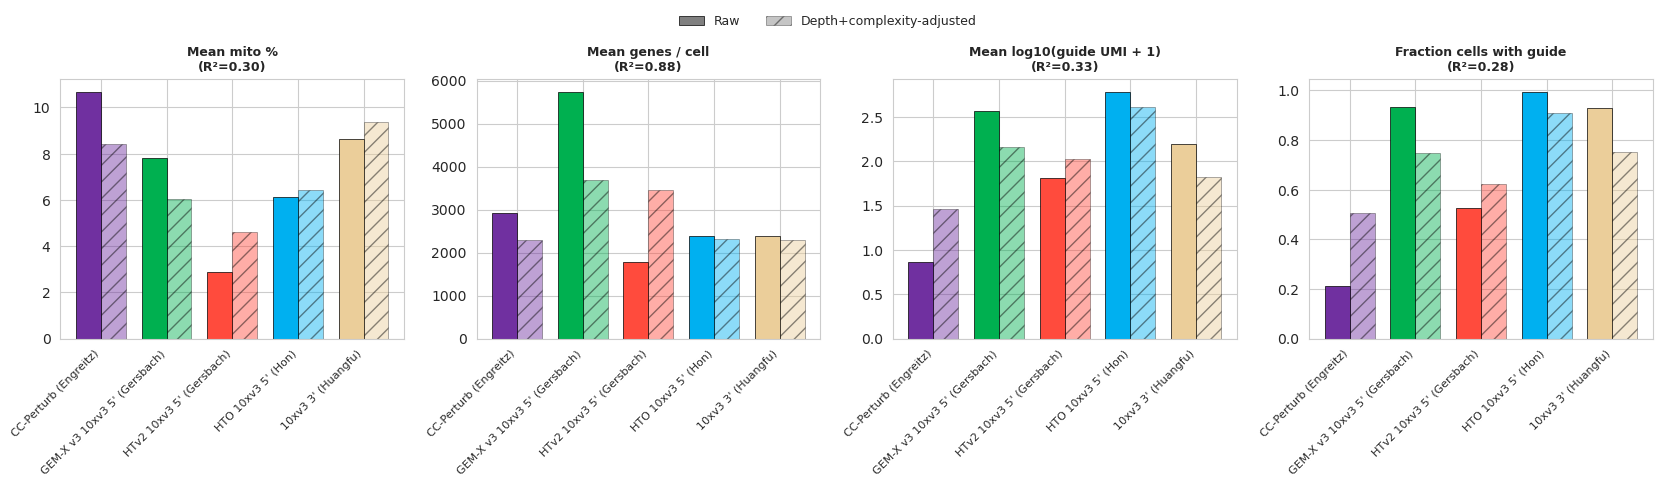

In [16]:
fig6, axes = plt.subplots(1, len(metrics_to_adjust), figsize=(4.2 * len(metrics_to_adjust), 4.6))
width = 0.38
x = np.arange(len(DATASET_NAMES))
for ax, (col, label) in zip(axes, metrics_to_adjust.items()):
    sub = adjust_plot_df[adjust_plot_df["metric"] == label]
    raw_vals = sub[sub["kind"] == "Raw"].set_index("dataset").loc[DATASET_NAMES, "value"].values
    adj_vals = sub[sub["kind"] == "Depth+complexity-adjusted"].set_index("dataset").loc[DATASET_NAMES, "value"].values
    colors = [COLOR_MAP[d] for d in DATASET_NAMES]
    ax.bar(x - width / 2, raw_vals, width, color=colors, edgecolor="black", linewidth=0.5)
    ax.bar(x + width / 2, adj_vals, width, color=colors, edgecolor="black", linewidth=0.5,
           alpha=0.45, hatch="//")
    ax.set_xticks(x)
    ax.set_xticklabels(DATASET_NAMES, rotation=45, ha="right", fontsize=8)
    r2_val = r2_df.loc[label, "r2_depth_complexity"]
    ax.set_title(f"{label}\n(R\u00b2={r2_val:.2f})", fontsize=9, fontweight="bold")

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="grey", edgecolor="black", linewidth=0.5, label="Raw"),
    plt.Rectangle((0, 0), 1, 1, facecolor="grey", edgecolor="black", linewidth=0.5, alpha=0.45,
                  hatch="//", label="Depth+complexity-adjusted"),
]
fig6.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.06), fontsize=9)
fig6.tight_layout()
fig6.savefig(os.path.join(OUT_DIR, "Q6c_depth_complexity_adjusted_barplots.png"), dpi=300, bbox_inches="tight")
plt.show()

## Figure 7: Per-library QC — are individual libraries driving the pattern?

For each dataset, looks for a library/batch/lane-type `obs` column (tries `LIBRARY_COL_CANDIDATES` via `resolve_library_col`, in order: `library_id`, `library`, `batch`, `lane`, `sample`, `sample_id`, `gem_group`, `GEM_group`, `channel`, `10x_lane`, `pool`, `batch_id`). Where more than one distinct value is found, cells are broken out per library for: cell count, depth, genes/cell, mito %, guide UMI, and fraction of cells with an assigned guide. This flags whether a dataset-level QC pattern from Figures 1–4 is uniform across the dataset's libraries or is actually being driven by one outlier library.

If no candidate column matches your `obs` schema, the cell below prints what it tried and the plot loop is skipped — update `LIBRARY_COL_CANDIDATES` / `resolve_library_col` with the real column name and rerun.

In [17]:
libraries_found = {
    name: sorted(cell_level_df.loc[cell_level_df["dataset"] == name, "library"].unique())
    for name in DATASET_NAMES
}
for name in DATASET_NAMES:
    libs = libraries_found[name]
    if libs == ["(no library column found)"]:
        print(f"{name}: no library/batch column found (tried {LIBRARY_COL_CANDIDATES})")
    else:
        print(f"{name}: {len(libs)} librar{'y' if len(libs) == 1 else 'ies'} -> {libs}")

datasets_with_libraries = [
    name for name in DATASET_NAMES
    if libraries_found[name] != ["(no library column found)"] and len(libraries_found[name]) > 1
]
if not datasets_with_libraries:
    print("\nNo dataset had a resolvable library/batch obs column with >1 distinct value -- "
          "the per-library plots below will be empty. Check LIBRARY_COL_CANDIDATES / "
          "resolve_library_col against the actual obs column name (e.g. mdata['gene'].obs.columns).")

CC-Perturb (Engreitz): 8 libraries -> ['IGVFDS0208BWWR', 'IGVFDS1283GTHY', 'IGVFDS1877QEAU', 'IGVFDS2550EQNC', 'IGVFDS3636ULPH', 'IGVFDS3696BCUD', 'IGVFDS4110WAOQ', 'IGVFDS4742SPAY']
GEM-X v3 10xv3 5' (Gersbach): 4 libraries -> ['IGVFDS2050UJNL', 'IGVFDS2155EXAM', 'IGVFDS3517WZCL', 'IGVFDS6100DRFR']
HTv2 10xv3 5' (Gersbach): 4 libraries -> ['IGVFDS0685OMIS', 'IGVFDS1940ANXO', 'IGVFDS2820AGVV', 'IGVFDS6261TOSA']
HTO 10xv3 5' (Hon): 3 libraries -> ['IGVFDS6244NAXC', 'IGVFDS8721BKRO', 'IGVFDS9613DDRB']
10xv3 3' (Huangfu): 4 libraries -> ['IGVFDS0471AYHF', 'IGVFDS1260YCMC', 'IGVFDS1889TBEY', 'IGVFDS5642SPLX']


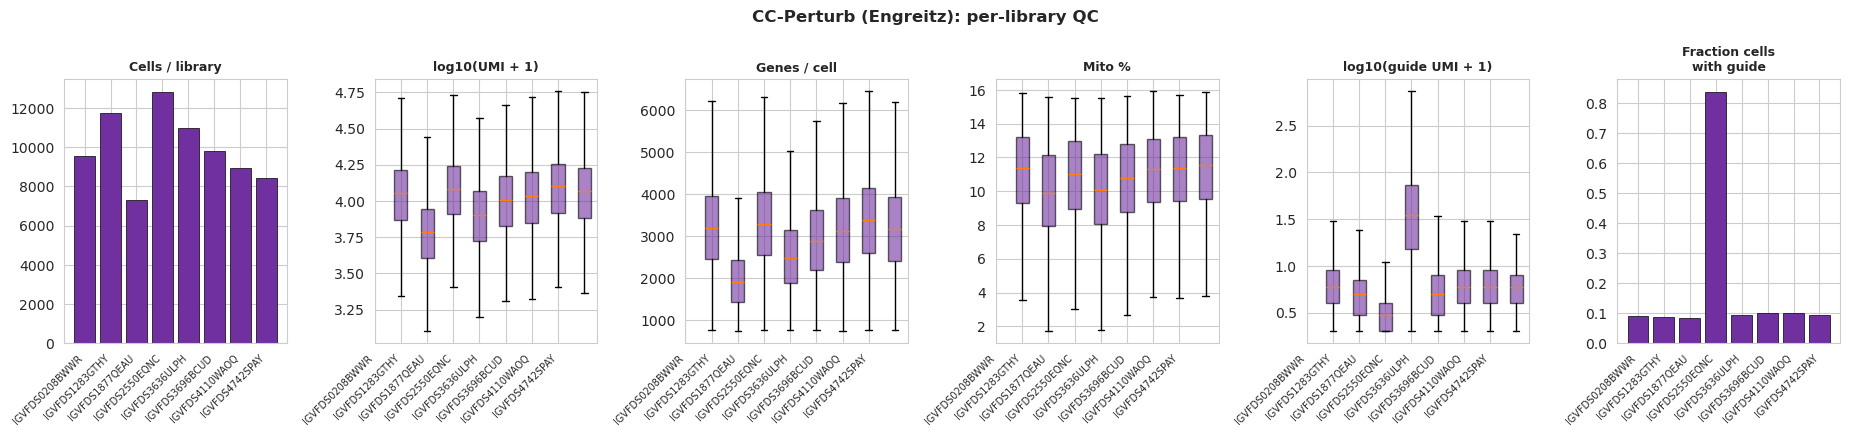

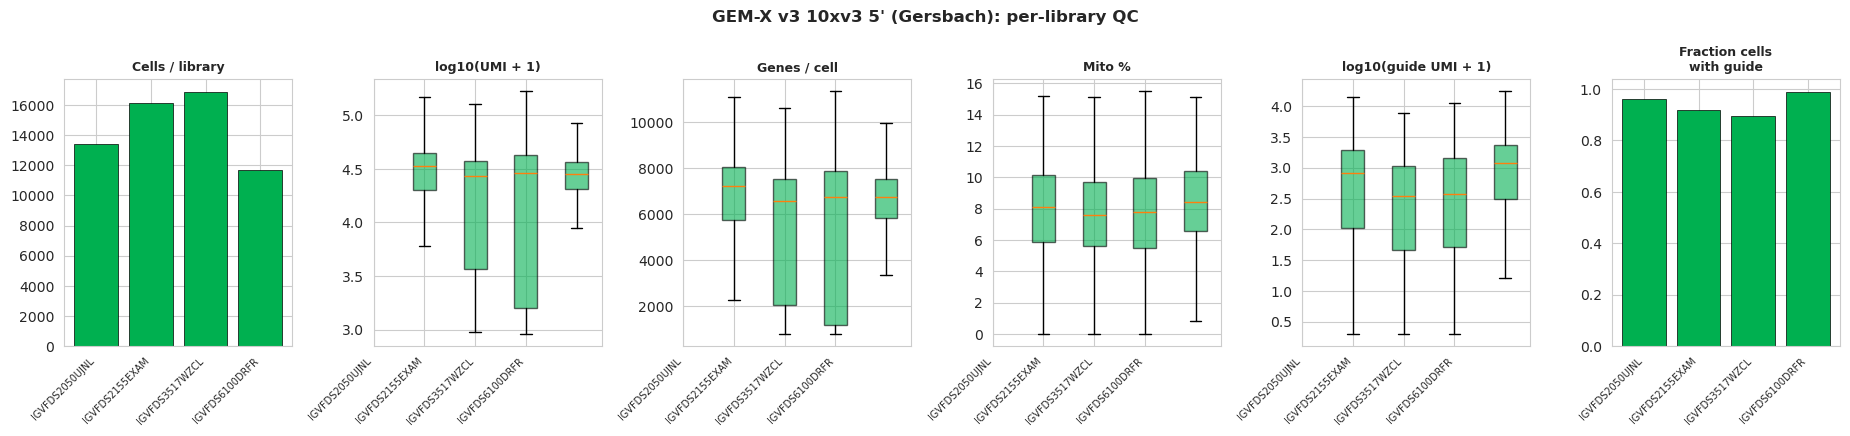

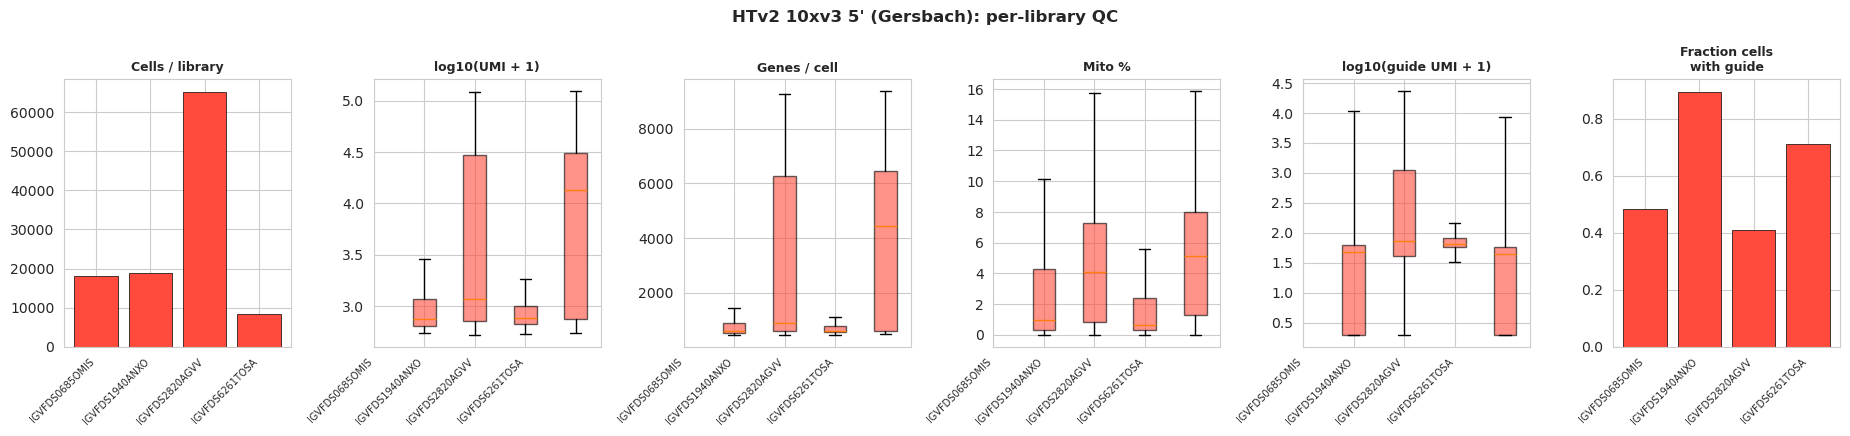

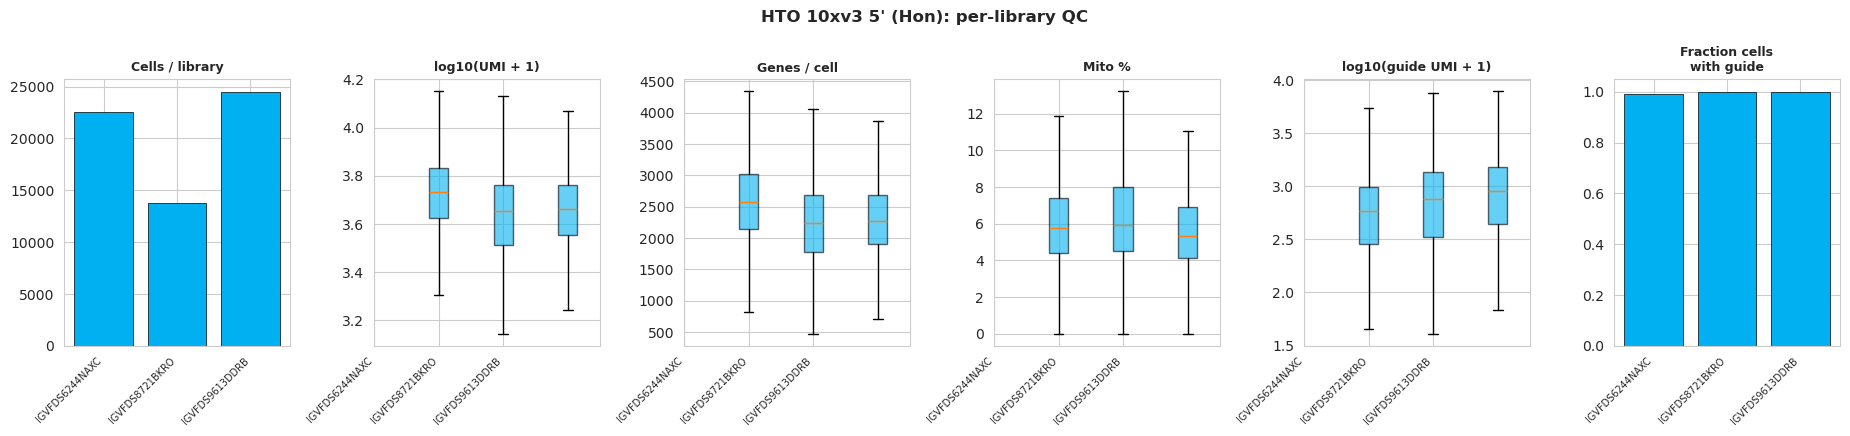

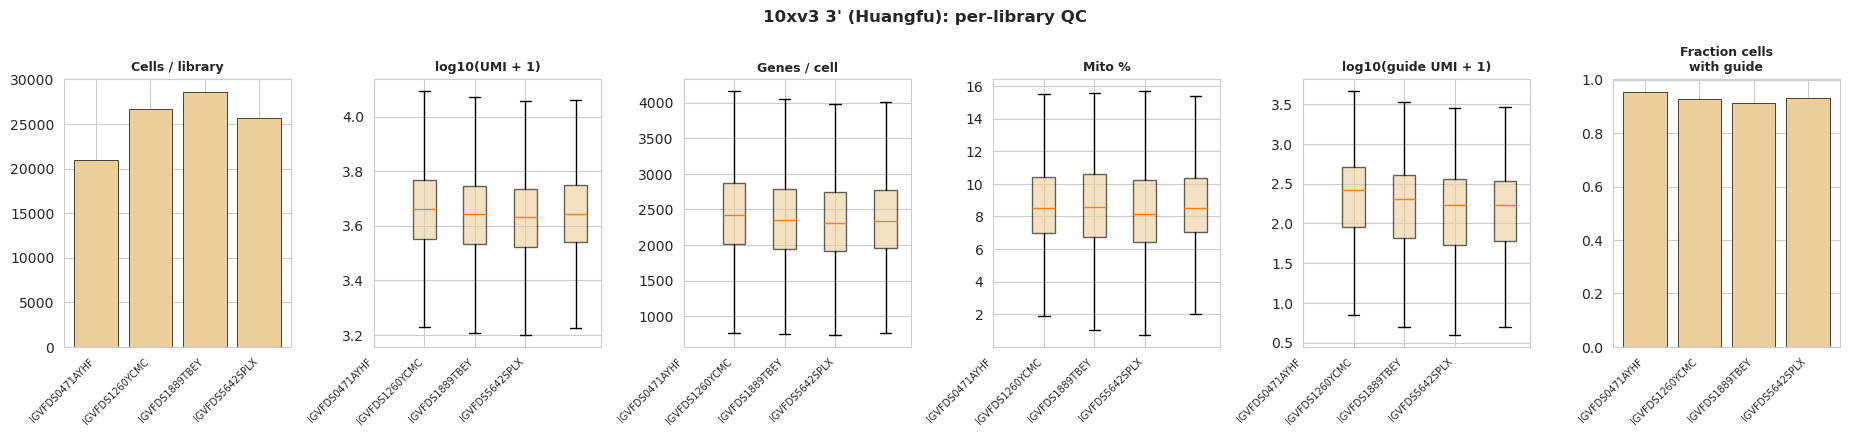

In [18]:
LIBRARY_METRICS = [
    ("log10_umi",       "log10(UMI + 1)"),
    ("n_genes",         "Genes / cell"),
    ("mito_pct",        "Mito %"),
    ("log10_guide_umi", "log10(guide UMI + 1)"),
]

for name in datasets_with_libraries:
    sub  = cell_level_df[cell_level_df["dataset"] == name]
    libs = libraries_found[name]

    n_panels = len(LIBRARY_METRICS) + 2  # + cells/library, + frac cells with guide
    fig, axes = plt.subplots(1, n_panels, figsize=(3.1 * n_panels, 4.4))

    counts = sub["library"].value_counts().reindex(libs)
    axes[0].bar(range(len(libs)), counts.values, color=COLOR_MAP[name], edgecolor="black", linewidth=0.5)
    axes[0].set_title("Cells / library", fontsize=9, fontweight="bold")

    for ax, (col, label) in zip(axes[1:], LIBRARY_METRICS):
        data = [sub.loc[sub["library"] == lib, col].dropna().values for lib in libs]
        bp = ax.boxplot(data, showfliers=False, patch_artist=True)
        for patch in bp["boxes"]:
            patch.set_facecolor(COLOR_MAP[name])
            patch.set_alpha(0.6)
        ax.set_title(label, fontsize=9, fontweight="bold")

    frac_guide = sub.groupby("library")["has_guide"].mean().reindex(libs)
    axes[-1].bar(range(len(libs)), frac_guide.values, color=COLOR_MAP[name], edgecolor="black", linewidth=0.5)
    axes[-1].set_title("Fraction cells\nwith guide", fontsize=9, fontweight="bold")

    for ax in axes:
        ax.set_xticks(range(len(libs)))
        ax.set_xticklabels(libs, rotation=45, ha="right", fontsize=7)

    fig.suptitle(f"{name}: per-library QC", fontweight="bold")
    fig.tight_layout()
    safe_name = (name.replace("/", "-").replace(" ", "_").replace("'", "")
                     .replace("(", "").replace(")", ""))
    fig.savefig(os.path.join(OUT_DIR, f"Q7_per_library_{safe_name}.png"), dpi=300, bbox_inches="tight")
    plt.show()

## Figure 8: Pseudobulk transcriptome comparison across datasets

Answers a more basic question than Figures 1-7: *ignoring perturbations/guides entirely, do the 5 datasets' transcriptomes look similar to begin with?* For each dataset, raw gene counts (`gene_ad.X`) are summed across **every cell** (no guide assignment or perturbation label is used anywhere in this section) to get one pseudobulk profile per dataset. Profiles are restricted to genes present (by symbol) in all 5 datasets' gene panels -- panel sizes differ (see `n_genes` in Figure 1), so this is a real restriction, not a formality -- then normalized to `log2(CPM + 1)`.

Caveat: this doesn't filter out mitochondrial or other highly technical genes, so if MT-genes (or any other small set of very high-count genes) dominate library size, they'll have an outsized pull on the correlations below. Worth re-running restricted to protein-coding / highly-variable genes if these figures look interesting and you want a sharper read.

In [19]:
shared_genes = sorted(set.intersection(*[set(s.index) for s in pseudobulk_by_ds.values()]))
print(f"{len(shared_genes)} genes shared by symbol across all {len(DATASET_NAMES)} datasets")
for name in DATASET_NAMES:
    n_total = len(pseudobulk_by_ds[name])
    print(f"  {name}: {n_total} genes total ({len(shared_genes) / n_total:.1%} in shared panel)")

pseudobulk_df = pd.DataFrame({name: pseudobulk_by_ds[name].reindex(shared_genes) for name in DATASET_NAMES})
cpm      = pseudobulk_df / pseudobulk_df.sum(axis=0) * 1e6
log2_cpm = np.log2(cpm + 1)

corr_pearson  = log2_cpm.corr(method="pearson")
corr_spearman = log2_cpm.corr(method="spearman")
corr_pearson.round(3)

8104 genes shared by symbol across all 5 datasets
  CC-Perturb (Engreitz): 10812 genes total (75.0% in shared panel)
  GEM-X v3 10xv3 5' (Gersbach): 13761 genes total (58.9% in shared panel)
  HTv2 10xv3 5' (Gersbach): 10097 genes total (80.3% in shared panel)
  HTO 10xv3 5' (Hon): 9479 genes total (85.5% in shared panel)
  10xv3 3' (Huangfu): 9139 genes total (88.7% in shared panel)


,CC-Perturb (Engreitz),GEM-X v3 10xv3 5' (Gersbach),HTv2 10xv3 5' (Gersbach),HTO 10xv3 5' (Hon),10xv3 3' (Huangfu)
CC-Perturb (Engreitz),1.000,0.858,0.826,0.721,0.840
GEM-X v3 10xv3 5' (Gersbach),0.858,1.000,0.984,0.941,0.873
HTv2 10xv3 5' (Gersbach),0.826,0.984,1.000,0.966,0.843
HTO 10xv3 5' (Hon),0.721,0.941,0.966,1.000,0.746
10xv3 3' (Huangfu),0.840,0.873,0.843,0.746,1.000


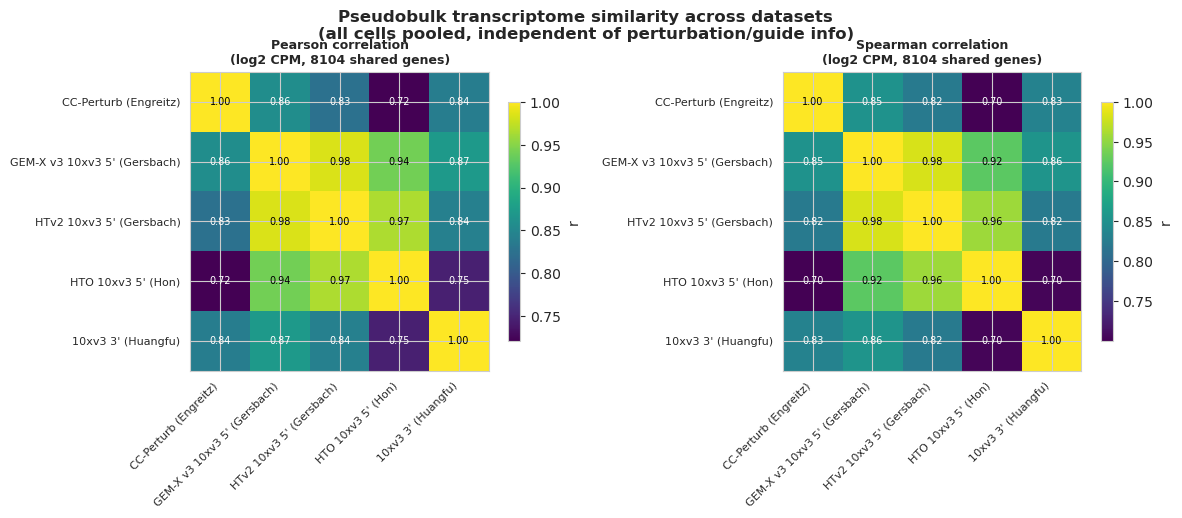

In [20]:
fig8a, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, corr, title in zip(axes, [corr_pearson, corr_spearman], ["Pearson", "Spearman"]):
    c = corr.loc[DATASET_NAMES, DATASET_NAMES].values
    im = ax.imshow(c, vmin=c.min(), vmax=1.0, cmap="viridis")
    ax.set_xticks(range(len(DATASET_NAMES)))
    ax.set_xticklabels(DATASET_NAMES, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(DATASET_NAMES)))
    ax.set_yticklabels(DATASET_NAMES, fontsize=8)
    threshold = c.min() + 0.7 * (1.0 - c.min())
    for i in range(len(DATASET_NAMES)):
        for j in range(len(DATASET_NAMES)):
            ax.text(j, i, f"{c[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if c[i, j] < threshold else "black")
    ax.set_title(f"{title} correlation\n(log2 CPM, {len(shared_genes)} shared genes)",
                 fontsize=9, fontweight="bold")
    fig8a.colorbar(im, ax=ax, shrink=0.8, label="r")
fig8a.suptitle("Pseudobulk transcriptome similarity across datasets\n"
               "(all cells pooled, independent of perturbation/guide info)", fontweight="bold")
fig8a.tight_layout()
fig8a.savefig(os.path.join(OUT_DIR, "Q8a_pseudobulk_correlation_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

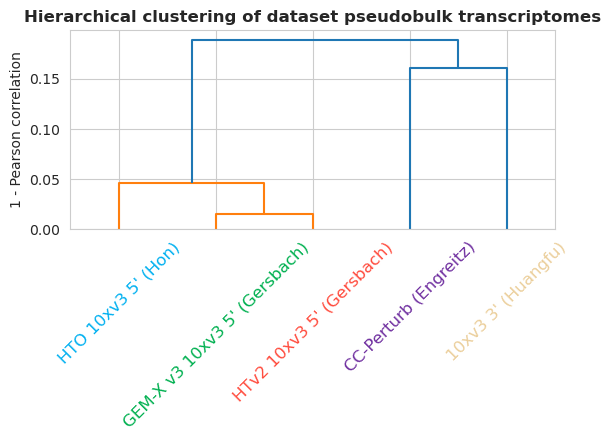

In [21]:
dist = 1 - corr_pearson.loc[DATASET_NAMES, DATASET_NAMES].values
np.fill_diagonal(dist, 0)
condensed = squareform(dist, checks=False)
Z = linkage(condensed, method="average")

fig8b, ax = plt.subplots(figsize=(6, 4.5))
dendrogram(Z, labels=DATASET_NAMES, ax=ax, leaf_rotation=45)
for lbl in ax.get_xticklabels():
    if lbl.get_text() in COLOR_MAP:
        lbl.set_color(COLOR_MAP[lbl.get_text()])
ax.set_ylabel("1 - Pearson correlation")
ax.set_title("Hierarchical clustering of dataset pseudobulk transcriptomes", fontweight="bold")
fig8b.tight_layout()
fig8b.savefig(os.path.join(OUT_DIR, "Q8b_pseudobulk_dendrogram.png"), dpi=300, bbox_inches="tight")
plt.show()

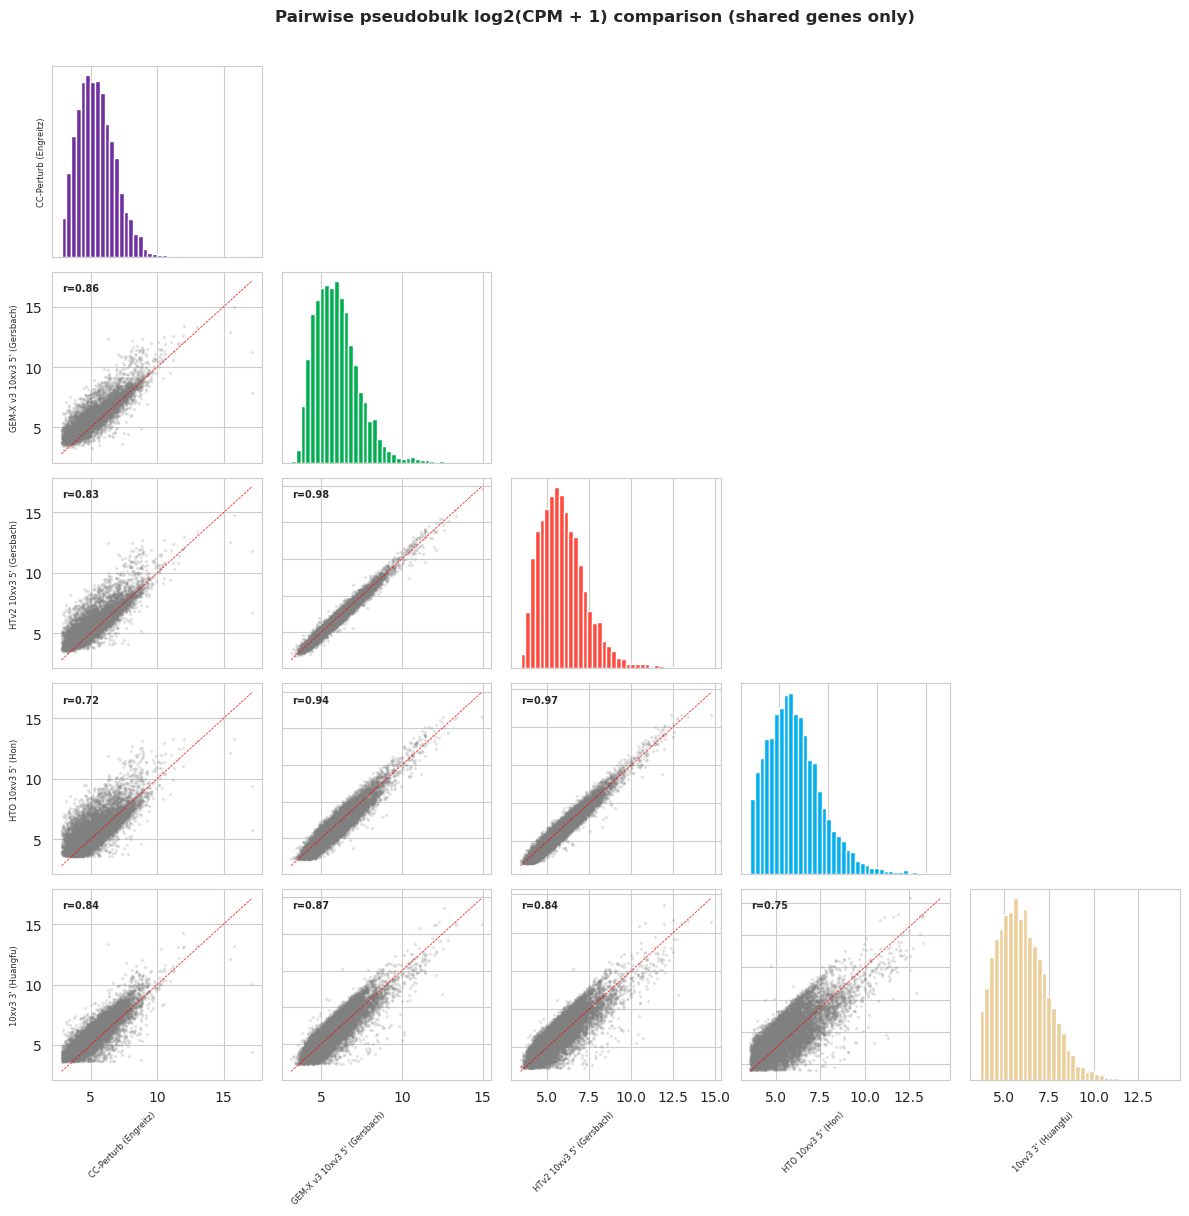

In [22]:
n = len(DATASET_NAMES)
fig8c, axes = plt.subplots(n, n, figsize=(2.4 * n, 2.4 * n))
for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        name_i, name_j = DATASET_NAMES[i], DATASET_NAMES[j]
        if i == j:
            ax.hist(log2_cpm[name_i], bins=40, color=COLOR_MAP[name_i])
            ax.set_yticks([])
        elif i > j:
            x = log2_cpm[name_j].values
            y = log2_cpm[name_i].values
            ax.scatter(x, y, s=2, alpha=0.15, color="grey", rasterized=True)
            r = corr_pearson.loc[name_i, name_j]
            ax.text(0.05, 0.90, f"r={r:.2f}", transform=ax.transAxes, fontsize=7, fontweight="bold")
            lims = [min(x.min(), y.min()), max(x.max(), y.max())]
            ax.plot(lims, lims, color="red", linewidth=0.5, linestyle="--")
        else:
            ax.axis("off")
        if i == n - 1:
            ax.set_xlabel(name_j, fontsize=6, rotation=45, ha="right")
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(name_i, fontsize=6)
        else:
            ax.set_yticklabels([])
fig8c.suptitle("Pairwise pseudobulk log2(CPM + 1) comparison (shared genes only)",
               fontweight="bold", y=1.01)
fig8c.tight_layout()
fig8c.savefig(os.path.join(OUT_DIR, "Q8c_pseudobulk_pairwise_scatter.png"), dpi=200, bbox_inches="tight")
plt.show()

## Figure 9: Downsampled comparisons — matched cells + matched transcripts, and matched cells + matched reads

Figures 1-4 compare the datasets *as sequenced*, so every panel confounds how much was sequenced with how well the assay worked. Figure 6 attacked that statistically (fit `metric ~ depth + complexity` and regress it out). This section attacks it by construction instead: physically downsample the data until the compared quantity is equal by design, then re-measure. Anything that still differs afterwards is not a depth effect.

Two matched designs, run on the **same cell sample** so they are directly comparable to each other and to the un-downsampled version of those same cells:

**Design 1 - matched cells + matched transcripts per cell.** Every dataset is reduced to the same number of cells (`N_CELLS`), and every retained cell is subsampled to exactly `TARGET_UMI` transcripts by drawing UMIs *without replacement* (multivariate hypergeometric over that cell's gene counts). This is the "same sequencing depth" comparison: genes detected per cell, mito %, and pseudobulk similarity become assay-efficiency readouts rather than depth readouts.

**Design 2 - matched cells + matched reads per cell.** Same cells, but now each cell's *reads* are subsampled to `TARGET_READS`. Because reads -> UMIs follows a saturation curve rather than a proportionality, equal reads produces **unequal** UMIs by design - that is the entire point. This is the "per sequencing dollar, which chemistry returns the most transcripts?" comparison, and here transcripts per cell is an outcome, not a control.

### How read subsampling is done

Raw reads are not in the MuData, so read subsampling is *modelled* rather than resampled. For a cell with `U` observed UMIs and `R` reads, the mean number of reads per observed molecule is `d = R / U` (necessarily >= 1, since a molecule is only observed if it got a read). Matching `d` to a zero-truncated Poisson gives a rate `lambda` solving `d = lambda / (1 - exp(-lambda))`. Subsampling reads to a fraction `p = TARGET_READS / R` then retains an expected fraction of molecules

```
keep(p) = expm1(-lambda * p) / expm1(-lambda)
```

which is the familiar saturation curve: `keep -> p` when every molecule has exactly one read (nothing to deduplicate, so molecules are lost in proportion to reads), and `keep -> 1` when molecules are deeply oversequenced (throwing away reads costs almost no molecules). Each cell is then subsampled to `round(U * keep(p))` UMIs by the same exact hypergeometric draw used in Design 1.

Per-cell read counts come from `obs` if a read-count column exists (`READS_OBS_CANDIDATES`); otherwise from a dataset-level read/UMI ratio derived from CellRanger's `metrics_summary.csv` (sequencing saturation preferred, else mean reads per cell), which is auto-searched next to the h5mu; otherwise from `READS_PER_CELL_OVERRIDE`, which you fill in by hand. **If read information cannot be found for even one dataset, Design 2 is skipped and only Design 1 runs** - Design 1 needs nothing beyond the count matrix and always works.

### Gene panels

With `RESTRICT_TO_SHARED_GENES = True` (default) the count matrices are first restricted to the `shared_genes` panel from Figure 8 (8,104 genes) before anything is counted or downsampled. Without this, "genes detected per cell" partly just measures panel size - the panels here range from 9,139 to 13,761 genes, and only 59-89% of each panel is shared - so a dataset could look more efficient purely for having been quantified against more genes.

### Reading the design table before trusting the figures

The target depth is set by the **shallowest** dataset, and the depth spread here is large (Figure 1: median UMI 790 for HTv2 vs 29,282 for GEM-X, ~37x). Matching all 5 therefore pulls everyone down to roughly HTv2's depth, which is an honest matched comparison but a lossy one - GEM-X discards the large majority of its molecules. The design table printed below reports the per-dataset fold reduction so this is explicit rather than buried. If the all-5 target is too shallow to be informative, re-run this section with `DOWNSAMPLE_DATASETS` set to the subset you want (e.g. all datasets except HTv2), or set `TARGET_UMI_OVERRIDE` directly; both are single-line changes in the config cell and nothing else needs editing.

### Caveats

- Design 2's read subsampling is a model, not a resample. The zero-truncated-Poisson assumption ignores overdispersion in per-molecule read depth, which makes it mildly optimistic about molecules retained at small `p`. If Design 2 turns out to be the headline result, re-derive it from `molecule_info.h5` where the per-molecule read counts are exact.
- Downsampling UMIs is exact, but it only equalises depth. It does not undo differences in ambient RNA, doublet rate, cell-calling thresholds, or reference/quantification pipeline.
- Cells are sampled at random from those meeting the depth threshold. If a dataset only qualifies via its deepest cells, it is being compared on that biased subset - the eligibility column in the design table reports what fraction of each dataset survived.
- Guide modality is never downsampled; guide metrics below reflect the matched *cell sample* only. Panel counts for genes are per matrix column, so a gene represented by two probes/IDs with the same symbol counts twice.

In [23]:
# ---- Figure 9 configuration ------------------------------------------------
DOWNSAMPLE_SEED = 0

# Which datasets take part. The target depth is set by the shallowest member,
# so dropping a very shallow dataset here raises the target for everyone else.
# e.g. [n for n in DATASET_NAMES if not n.startswith("HTv2")]
DOWNSAMPLE_DATASETS = list(DATASET_NAMES)

# Target depth = the smallest, across participating datasets, of this quantile
# of the per-cell depth distribution. Lower quantile -> shallower target but
# more cells stay eligible; higher quantile -> deeper target, fewer cells.
UMI_QUANTILE  = 0.20
READ_QUANTILE = 0.20

# Set either of these to a number to pin the target explicitly and ignore the
# quantile rule (useful for "match everyone to 2000 UMI" style requests).
TARGET_UMI_OVERRIDE   = None
TARGET_READS_OVERRIDE = None

# Restrict to the genes shared by all panels (`shared_genes`, from Figure 8)
# before downsampling. Strongly recommended - panel sizes differ, so genes
# detected per cell is not comparable across datasets otherwise.
RESTRICT_TO_SHARED_GENES = True

# Cap on the matched cell count, mostly a runtime guard (downsampling is one
# hypergeometric draw per cell). None = use the smallest eligible dataset.
MAX_CELLS = None

# Per-cell read counts are rarely stored in obs, but check anyway.
READS_OBS_CANDIDATES = [
    "total_reads", "n_reads", "num_reads", "reads", "total_read_counts",
    "raw_reads", "nCount_reads", "n_reads_total", "reads_per_cell",
]

# Manual fallback for Design 2, consulted before metrics_summary.csv. Give each
# dataset EITHER "sequencing_saturation" (fraction, e.g. 0.62) OR
# "mean_reads_per_cell" (e.g. 42000) - both are printed by CellRanger.
READS_PER_CELL_OVERRIDE = {
    # "CC-Perturb (Engreitz)":        {"sequencing_saturation": 0.62},
    # "GEM-X v3 10xv3 5' (Gersbach)": {"mean_reads_per_cell": 42000},
}

DOWNSAMPLE_DATASETS = [n for n in DATASET_NAMES if n in set(DOWNSAMPLE_DATASETS)]
print(f"Datasets participating in Figure 9: {DOWNSAMPLE_DATASETS}")

Datasets participating in Figure 9: ['CC-Perturb (Engreitz)', "GEM-X v3 10xv3 5' (Gersbach)", "HTv2 10xv3 5' (Gersbach)", "HTO 10xv3 5' (Hon)", "10xv3 3' (Huangfu)"]


In [24]:
def _is_integral(X, n_check=200_000):
    """Cheap check that a matrix holds counts rather than normalised values."""
    vals = X.data[:n_check] if sp.issparse(X) else np.asarray(X).ravel()[:n_check]
    if vals.size == 0:
        return True
    vals = np.asarray(vals, dtype=float)
    return np.all(np.isfinite(vals)) and np.allclose(vals, np.round(vals))


def get_raw_counts(gene_ad):
    """Raw integer counts. Prefers layers['counts'] if X has been normalised."""
    if "counts" in getattr(gene_ad, "layers", {}) and _is_integral(gene_ad.layers["counts"]):
        return gene_ad.layers["counts"]
    if not _is_integral(gene_ad.X):
        raise ValueError(
            "gene_ad.X is not integer-valued and no integer 'counts' layer was found. "
            "Downsampling requires raw counts - point get_raw_counts() at the right layer. "
            f"Available layers: {list(getattr(gene_ad, 'layers', {}).keys())}"
        )
    return gene_ad.X


def get_gene_matrix(gene_ad, restrict_to=None):
    """(counts matrix, gene symbols), optionally restricted to a symbol set."""
    X = get_raw_counts(gene_ad)
    symbol_col = resolve_gene_symbol_col(gene_ad)
    symbols = (gene_ad.var[symbol_col].astype(str) if symbol_col
               else pd.Series(gene_ad.var_names.astype(str))).values
    if restrict_to is not None:
        keep = np.flatnonzero(np.isin(symbols, np.asarray(list(restrict_to))))
        X = X[:, keep]
        symbols = symbols[keep]
    return sp.csr_matrix(X), symbols


def downsample_rows(X, targets, rng, log_every=25_000, label=""):
    """Subsample each row of a count matrix to targets[i] UMIs, without
    replacement (multivariate hypergeometric over that row's gene counts).
    Rows already at or below their target are passed through unchanged."""
    X = sp.csr_matrix(X)
    data = np.asarray(X.data)
    if not _is_integral(X):
        raise ValueError("downsample_rows expects integer counts")
    data = np.rint(data).astype(np.int64)
    out = np.zeros_like(data)
    indptr, targets = X.indptr, np.asarray(targets)
    for i in range(X.shape[0]):
        s, e = indptr[i], indptr[i + 1]
        if e == s:
            continue
        row = data[s:e]
        t = int(targets[i])
        if t <= 0:
            continue
        if t >= int(row.sum()):
            out[s:e] = row
        else:
            out[s:e] = rng.multivariate_hypergeometric(row, t)
        if log_every and i and i % log_every == 0:
            print(f"      {label}{i:,}/{X.shape[0]:,} cells")
    Y = sp.csr_matrix((out.astype(np.int32), X.indices.copy(), X.indptr.copy()), shape=X.shape)
    Y.eliminate_zeros()
    return Y


def solve_ztp_lambda(d, n_iter=100):
    """Solve d = lambda / (1 - exp(-lambda)) for lambda, elementwise, by
    bisection. `d` is mean reads per *observed* molecule, so d >= 1; d <= 1
    means one read per molecule, which is the lambda -> 0 limit."""
    d = np.asarray(d, dtype=float)
    lo = np.full(d.shape, 1e-9)
    hi = np.full(d.shape, 1e4)
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        f = mid / -np.expm1(-mid)          # 1 - exp(-mid), stable
        too_deep = f > d
        hi = np.where(too_deep, mid, hi)
        lo = np.where(too_deep, lo, mid)
    lam = 0.5 * (lo + hi)
    return np.where(np.isfinite(d) & (d > 1.0 + 1e-9), lam, 1e-9)


def read_subsample_keep_fraction(lam, p):
    """Expected fraction of observed molecules surviving when reads are
    subsampled at rate p. expm1 form is stable for both tiny and large lambda;
    equals p at lambda -> 0 and -> 1 for heavily oversequenced molecules."""
    p = np.clip(np.asarray(p, dtype=float), 0.0, 1.0)
    return np.expm1(-lam * p) / np.expm1(-lam)


def _parse_metric_value(v):
    s = str(v).strip().replace(",", "")
    pct = s.endswith("%")
    s = s[:-1] if pct else s
    try:
        x = float(s)
    except ValueError:
        return None
    return x / 100.0 if pct else x


def find_metrics_summary(ds, max_depth=3):
    """Shallow search for CellRanger metrics_summary.csv under the dataset dir."""
    root = os.path.join(BASE_DIR, ds["dir"])
    if not os.path.isdir(root):
        return []
    base_depth = root.rstrip(os.sep).count(os.sep)
    hits = []
    for dirpath, dirnames, filenames in os.walk(root):
        if dirpath.count(os.sep) - base_depth >= max_depth:
            dirnames[:] = []
        for fn in filenames:
            if fn.lower() == "metrics_summary.csv":
                hits.append(os.path.join(dirpath, fn))
    return sorted(hits)


def _metric_lookup(path, wanted):
    """Pull a metric out of metrics_summary.csv in either the wide (one row,
    metric names as columns) or long ('Metric Name'/'Metric Value') layout.
    Averages over rows when a run has several libraries."""
    try:
        m = pd.read_csv(path)
    except Exception:
        return None
    cols = {str(c).strip().lower(): c for c in m.columns}
    if "metric name" in cols and "metric value" in cols:
        sub = m[m[cols["metric name"]].astype(str).str.strip().str.lower().isin(wanted)]
        vals = [_parse_metric_value(v) for v in sub[cols["metric value"]]]
    else:
        hit = next((cols[w] for w in wanted if w in cols), None)
        if hit is None:
            return None
        vals = [_parse_metric_value(v) for v in m[hit]]
    vals = [v for v in vals if v is not None]
    return float(np.mean(vals)) if vals else None


def dataset_read_model(ds):
    """(kind, value, provenance) describing how to turn UMIs into reads."""
    ov = READS_PER_CELL_OVERRIDE.get(ds["display_name"], {})
    for kind in ("sequencing_saturation", "mean_reads_per_cell"):
        if kind in ov:
            return kind, float(ov[kind]), "READS_PER_CELL_OVERRIDE"
    for path in find_metrics_summary(ds):
        sat = _metric_lookup(path, {"sequencing saturation", "sequencing_saturation"})
        if sat is not None and 0.0 < sat < 1.0:
            return "sequencing_saturation", sat, path
        mrc = _metric_lookup(path, {"mean reads per cell", "mean_reads_per_cell"})
        if mrc is not None and mrc > 0:
            return "mean_reads_per_cell", mrc, path
    return None, None, None


def resolve_reads_per_cell(ds, gene_ad, umi_full):
    """Per-cell read counts, exact from obs where possible, else scaled from a
    dataset-level read/UMI ratio. Returns (reads array or None, provenance)."""
    for col in READS_OBS_CANDIDATES:
        if col in gene_ad.obs.columns:
            reads = pd.to_numeric(gene_ad.obs[col], errors="coerce").values.astype(float)
            if np.isfinite(reads).sum() > 0.5 * len(reads):
                return reads, f"obs['{col}']"
    kind, value, provenance = dataset_read_model(ds)
    if kind == "sequencing_saturation":
        return umi_full / (1.0 - value), f"saturation={value:.3f} ({provenance})"
    if kind == "mean_reads_per_cell":
        d = value / max(np.mean(umi_full), 1.0)
        return umi_full * d, f"mean reads/cell={value:,.0f} -> {d:.2f} reads/UMI ({provenance})"
    return None, "not found"


def guide_metrics_for_cells(guide_ad, idx):
    """Guide QC for a subset of cells. Mirrors the logic in the main load loop
    (cell 5) so the matched-cell numbers stay comparable to Figures 2 and 4."""
    assignment = get_guide_assignment(guide_ad)[idx]
    target_col = resolve_guide_target_col(guide_ad)
    gene_names = guide_ad.var[target_col].astype(str).values
    is_nt = (gene_names == NON_TARGETING_LABEL)

    n_hits = assignment.sum(axis=1)
    targeting_mask = (assignment[:, ~is_nt] > 0)
    has_targeting = targeting_mask.any(axis=1)
    first_targ_idx = targeting_mask.argmax(axis=1)

    assigned = np.where(has_targeting, gene_names[~is_nt][first_targ_idx],
                        NON_TARGETING_LABEL).astype(object)
    assigned[n_hits == 0] = None
    return {
        "n_guides":    n_hits,
        "has_guide":   (n_hits > 0).astype(int),
        "guide_umi":   row_sum(guide_ad.X)[idx],
        "assigned_tf": assigned,
    }

In [25]:
# ---- Pass 1/2: per-cell depth and read counts (no matrices retained) -------
gene_panel = set(shared_genes) if RESTRICT_TO_SHARED_GENES else None
print(f"Gene panel: {'shared only (' + str(len(shared_genes)) + ' genes)' if gene_panel else 'full per-dataset panel'}\n")

depth_by_ds, reads_source = {}, {}
for ds in DATASETS:
    name = ds["display_name"]
    if name not in DOWNSAMPLE_DATASETS:
        continue
    print(f"[pass 1/2] {name}")
    mdata = mudata.read_h5mu(resolve_h5mu_path(ds))
    gene_ad = mdata["gene"]

    X_full, _ = get_gene_matrix(gene_ad)
    umi_full = row_sum(X_full)
    if gene_panel is not None:
        X_panel, _ = get_gene_matrix(gene_ad, restrict_to=gene_panel)
        umi_panel = row_sum(X_panel)
        del X_panel
    else:
        umi_panel = umi_full

    reads, source = resolve_reads_per_cell(ds, gene_ad, umi_full)
    reads_source[name] = source
    print(f"  reads/cell: {source}")
    print(f"  median UMI {np.median(umi_panel):,.0f} (panel) / {np.median(umi_full):,.0f} (full)")

    depth_by_ds[name] = {"umi_panel": umi_panel, "umi_full": umi_full, "reads": reads}
    del mdata, gene_ad, X_full
    gc.collect()

RUN_DESIGN2 = all(depth_by_ds[n]["reads"] is not None for n in DOWNSAMPLE_DATASETS)
if not RUN_DESIGN2:
    missing = [n for n in DOWNSAMPLE_DATASETS if depth_by_ds[n]["reads"] is None]
    print("\n" + "!" * 78)
    print("Design 2 (matched reads) SKIPPED - no per-cell read counts and no dataset-level")
    print("read model for: " + ", ".join(missing))
    print("Fix by filling READS_PER_CELL_OVERRIDE with sequencing saturation or mean reads")
    print("per cell from each run's CellRanger metrics_summary.csv, then re-run this cell.")
    print("Design 1 (matched transcripts) is unaffected and runs below.")
    print("!" * 78)
else:
    print("\nDesign 2 (matched reads) will run - read model available for all datasets.")

Gene panel: shared only (8104 genes)

[pass 1/2] CC-Perturb (Engreitz)
  reads/cell: not found
  median UMI 7,794 (panel) / 9,808 (full)
[pass 1/2] GEM-X v3 10xv3 5' (Gersbach)
  reads/cell: not found
  median UMI 27,684 (panel) / 29,282 (full)
[pass 1/2] HTv2 10xv3 5' (Gersbach)
  reads/cell: not found
  median UMI 766 (panel) / 790 (full)
[pass 1/2] HTO 10xv3 5' (Hon)
  reads/cell: not found
  median UMI 4,647 (panel) / 4,853 (full)
[pass 1/2] 10xv3 3' (Huangfu)
  reads/cell: not found
  median UMI 4,309 (panel) / 4,392 (full)

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Design 2 (matched reads) SKIPPED - no per-cell read counts and no dataset-level
read model for: CC-Perturb (Engreitz), GEM-X v3 10xv3 5' (Gersbach), HTv2 10xv3 5' (Gersbach), HTO 10xv3 5' (Hon), 10xv3 3' (Huangfu)
Fix by filling READS_PER_CELL_OVERRIDE with sequencing saturation or mean reads
per cell from each run's CellRanger metrics_summary.csv, then re-run this cell.
Design 1 (m

In [26]:
# ---- Targets: depth set by the shallowest dataset, cells by the smallest ---
umi_q = {n: float(np.quantile(depth_by_ds[n]["umi_panel"], UMI_QUANTILE)) for n in DOWNSAMPLE_DATASETS}
TARGET_UMI = int(TARGET_UMI_OVERRIDE if TARGET_UMI_OVERRIDE is not None else np.floor(min(umi_q.values())))
umi_binding = min(umi_q, key=umi_q.get)

eligible = {n: (depth_by_ds[n]["umi_panel"] >= TARGET_UMI) for n in DOWNSAMPLE_DATASETS}

if RUN_DESIGN2:
    read_q = {n: float(np.quantile(depth_by_ds[n]["reads"], READ_QUANTILE)) for n in DOWNSAMPLE_DATASETS}
    TARGET_READS = int(TARGET_READS_OVERRIDE if TARGET_READS_OVERRIDE is not None else np.floor(min(read_q.values())))
    reads_binding = min(read_q, key=read_q.get)
    for n in DOWNSAMPLE_DATASETS:
        eligible[n] = eligible[n] & (depth_by_ds[n]["reads"] >= TARGET_READS)
else:
    TARGET_READS, reads_binding, read_q = None, None, {}

N_CELLS = min(int(eligible[n].sum()) for n in DOWNSAMPLE_DATASETS)
if MAX_CELLS is not None:
    N_CELLS = min(N_CELLS, int(MAX_CELLS))
cells_binding = min(DOWNSAMPLE_DATASETS, key=lambda n: int(eligible[n].sum()))

rows = []
for n in DOWNSAMPLE_DATASETS:
    d = depth_by_ds[n]
    rows.append({
        "median UMI (panel)":     float(np.median(d["umi_panel"])),
        "UMI fold reduction":     float(np.median(d["umi_panel"])) / TARGET_UMI,
        "median reads":           float(np.median(d["reads"])) if RUN_DESIGN2 else np.nan,
        "read fold reduction":    (float(np.median(d["reads"])) / TARGET_READS) if RUN_DESIGN2 else np.nan,
        "cells total":            len(d["umi_panel"]),
        "cells eligible":         int(eligible[n].sum()),
        "frac eligible":          float(eligible[n].mean()),
        "frac of dataset used":   N_CELLS / len(d["umi_panel"]),
    })
downsample_design_df = pd.DataFrame(rows, index=DOWNSAMPLE_DATASETS)

print(f"TARGET_UMI   = {TARGET_UMI:,} transcripts/cell   (set by {umi_binding} at q={UMI_QUANTILE})")
if RUN_DESIGN2:
    print(f"TARGET_READS = {TARGET_READS:,} reads/cell         (set by {reads_binding} at q={READ_QUANTILE})")
print(f"N_CELLS      = {N_CELLS:,} cells/dataset      (limited by {cells_binding})")

worst = downsample_design_df["UMI fold reduction"].max()
if worst > 10:
    print(f"\nNOTE: the deepest dataset is being cut {worst:.0f}x to reach TARGET_UMI. That is a")
    print("real matched comparison but a lossy one. To trade breadth for depth, drop the")
    print("shallowest dataset from DOWNSAMPLE_DATASETS and re-run from the config cell:")
    print(f'  DOWNSAMPLE_DATASETS = [n for n in DATASET_NAMES if n != "{umi_binding}"]')

downsample_design_df.round(3)

TARGET_UMI   = 631 transcripts/cell   (set by HTv2 10xv3 5' (Gersbach) at q=0.2)
N_CELLS      = 58,113 cells/dataset      (limited by GEM-X v3 10xv3 5' (Gersbach))

NOTE: the deepest dataset is being cut 44x to reach TARGET_UMI. That is a
real matched comparison but a lossy one. To trade breadth for depth, drop the
shallowest dataset from DOWNSAMPLE_DATASETS and re-run from the config cell:
  DOWNSAMPLE_DATASETS = [n for n in DATASET_NAMES if n != "HTv2 10xv3 5' (Gersbach)"]


,median UMI (panel),UMI fold reduction,median reads,read fold reduction,cells total,cells eligible,frac eligible,frac of dataset used
CC-Perturb (Engreitz),7794.5,12.353,NaN,NaN,79596,79596,1.000,0.730
GEM-X v3 10xv3 5' (Gersbach),27684.0,43.873,NaN,NaN,58113,58113,1.000,1.000
HTv2 10xv3 5' (Gersbach),766.0,1.214,NaN,NaN,110339,88534,0.802,0.527
HTO 10xv3 5' (Hon),4647.0,7.365,NaN,NaN,60817,60763,0.999,0.956
10xv3 3' (Huangfu),4309.0,6.829,NaN,NaN,101939,101939,1.000,0.570


In [27]:
# ---- Pass 2/2: sample matched cells, downsample, re-measure ---------------
COND_CELLS = "Matched cells only"
COND_UMI   = "Matched cells + UMI"
COND_READS = "Matched cells + reads"
CONDITIONS = [COND_CELLS, COND_UMI] + ([COND_READS] if RUN_DESIGN2 else [])

ds_cell_records, ds_pseudobulk, ds_tf_counts = [], {}, {}

for k, ds in enumerate(d for d in DATASETS if d["display_name"] in DOWNSAMPLE_DATASETS):
    name = ds["display_name"]
    rng = np.random.default_rng(DOWNSAMPLE_SEED + k)
    print(f"\n[pass 2/2] {name}")

    mdata = mudata.read_h5mu(resolve_h5mu_path(ds))
    gene_ad, guide_ad = mdata["gene"], mdata["guide"]

    X, symbols = get_gene_matrix(gene_ad, restrict_to=gene_panel)
    idx = np.sort(rng.choice(np.flatnonzero(eligible[name]), size=N_CELLS, replace=False))
    X = X[idx]
    mito_mask = pd.Series(symbols).str.upper().str.startswith("MT-").values
    guide = guide_metrics_for_cells(guide_ad, idx)
    print(f"  sampled {N_CELLS:,} of {int(eligible[name].sum()):,} eligible cells")

    # Design 1: every cell to exactly TARGET_UMI transcripts.
    print(f"  downsampling to {TARGET_UMI:,} UMI/cell ...")
    X_umi = downsample_rows(X, np.full(X.shape[0], TARGET_UMI), rng, label="UMI ")

    # Design 2: every cell to TARGET_READS reads, via the saturation curve.
    if RUN_DESIGN2:
        umi_full = depth_by_ds[name]["umi_full"][idx]
        reads    = depth_by_ds[name]["reads"][idx]
        lam      = solve_ztp_lambda(reads / np.maximum(umi_full, 1))
        keep     = read_subsample_keep_fraction(lam, TARGET_READS / reads)
        targets  = np.maximum(np.rint(row_sum(X) * keep), 0).astype(np.int64)
        print(f"  downsampling to {TARGET_READS:,} reads/cell "
              f"(median {np.median(reads / np.maximum(umi_full, 1)):.2f} reads/UMI, "
              f"keeping {np.median(keep):.1%} of molecules -> {np.median(targets):,.0f} UMI/cell) ...")
        X_reads = downsample_rows(X, targets, rng, label="reads ")
    else:
        X_reads = None

    for cond, mat in [(COND_CELLS, X), (COND_UMI, X_umi), (COND_READS, X_reads)]:
        if mat is None:
            continue
        total = row_sum(mat)
        n_genes = row_sum(mat > 0)
        if mito_mask.sum() > 0:
            with np.errstate(divide="ignore", invalid="ignore"):
                mito_pct = np.where(total > 0, row_sum(mat[:, mito_mask]) / total * 100, 0.0)
        else:
            mito_pct = np.full(mat.shape[0], np.nan)

        ds_cell_records.append(pd.DataFrame({
            "dataset": name, "condition": cond,
            "total_counts": total, "log10_umi": np.log10(total + 1),
            "n_genes": n_genes, "mito_pct": mito_pct,
            "complexity": compute_novelty_score(n_genes, total),
            "n_guides": guide["n_guides"], "has_guide": guide["has_guide"],
            "guide_umi": guide["guide_umi"],
            "log10_guide_umi": np.log10(guide["guide_umi"] + 1),
        }))
        ds_pseudobulk[(cond, name)] = (pd.Series(np.asarray(mat.sum(axis=0)).ravel(), index=symbols)
                                         .groupby(level=0).sum())

    tf = pd.Series(guide["assigned_tf"])
    ds_tf_counts[name] = tf[tf.notna() & (tf != NON_TARGETING_LABEL)].value_counts()

    del mdata, gene_ad, guide_ad, X, X_umi, X_reads
    gc.collect()

ds_cell_df = pd.concat(ds_cell_records, ignore_index=True)
print(f"\nDone. {len(ds_cell_df):,} cell-condition rows across {len(CONDITIONS)} conditions.")


[pass 2/2] CC-Perturb (Engreitz)
  sampled 58,113 of 79,596 eligible cells
  downsampling to 631 UMI/cell ...
      UMI 25,000/58,113 cells
      UMI 50,000/58,113 cells

[pass 2/2] GEM-X v3 10xv3 5' (Gersbach)
  sampled 58,113 of 58,113 eligible cells
  downsampling to 631 UMI/cell ...
      UMI 25,000/58,113 cells
      UMI 50,000/58,113 cells

[pass 2/2] HTv2 10xv3 5' (Gersbach)
  sampled 58,113 of 88,534 eligible cells
  downsampling to 631 UMI/cell ...
      UMI 25,000/58,113 cells
      UMI 50,000/58,113 cells

[pass 2/2] HTO 10xv3 5' (Hon)
  sampled 58,113 of 60,763 eligible cells
  downsampling to 631 UMI/cell ...
      UMI 25,000/58,113 cells
      UMI 50,000/58,113 cells

[pass 2/2] 10xv3 3' (Huangfu)
  sampled 58,113 of 101,939 eligible cells
  downsampling to 631 UMI/cell ...
      UMI 25,000/58,113 cells
      UMI 50,000/58,113 cells

Done. 581,130 cell-condition rows across 2 conditions.


In [28]:
# ---- Summary table: as sequenced vs each matched design -------------------
def _summarise(df, label):
    out = df.groupby("dataset").agg(
        median_umi=("total_counts", "median"),
        median_genes=("n_genes", "median"),
        mean_mito_pct=("mito_pct", "mean"),
        median_complexity=("complexity", "median"),
        frac_cells_with_guide=("has_guide", "mean"),
        median_guide_umi=("guide_umi", "median"),
        n_cells=("dataset", "size"),
    )
    out.insert(0, "condition", label)
    return out

pieces = [_summarise(cell_level_df[cell_level_df["dataset"].isin(DOWNSAMPLE_DATASETS)],
                     "All cells, as sequenced (full panel)")]
pieces += [_summarise(ds_cell_df[ds_cell_df["condition"] == c], c) for c in CONDITIONS]

downsample_summary = (pd.concat(pieces)
                        .reset_index()
                        .set_index(["condition", "dataset"])
                        .loc[[p["condition"].iloc[0] for p in pieces]])
downsample_summary.round(2)

median_umi  \
condition                            dataset                                    
All cells, as sequenced (full panel) 10xv3 3' (Huangfu)                4392.0   
                                     CC-Perturb (Engreitz)             9808.0   
                                     GEM-X v3 10xv3 5' (Gersbach)     29282.0   
                                     HTO 10xv3 5' (Hon)                4853.0   
                                     HTv2 10xv3 5' (Gersbach)           790.0   
Matched cells only                   10xv3 3' (Huangfu)                4309.0   
                                     CC-Perturb (Engreitz)             7779.0   
                                     GEM-X v3 10xv3 5' (Gersbach)     27684.0   
                                     HTO 10xv3 5' (Hon)                4646.0   
                                     HTv2 10xv3 5' (Gersbach)           850.0   
Matched cells + UMI                  10xv3 3' (Huangfu)                 631.0   
                                     CC-Perturb (Engreitz)              631.0   
                                     GEM-X v3 10xv3 5' (Gersbach)       631.0   
                                     HTO 10xv3 5' (Hon)                 631.0   
                                     HTv2 10xv3 5' (Gersbach)           631.0   

                                                                   median_genes  \
condition                            dataset                                      
All cells, as sequenced (full panel) 10xv3 3' (Huangfu)                  2350.0   
                                     CC-Perturb (Engreitz)               2834.0   
                                     GEM-X v3 10xv3 5' (Gersbach)        6803.0   
                                     HTO 10xv3 5' (Hon)                  2372.0   
                                     HTv2 10xv3 5' (Gersbach)             637.0   
Matched cells only                   10xv3 3' (Huangfu)                  2274.0   
                                     CC-Perturb (Engreitz)               2500.0   
                                     GEM-X v3 10xv3 5' (Gersbach)        5703.0   
                                     HTO 10xv3 5' (Hon)                  2201.0   
                                     HTv2 10xv3 5' (Gersbach)             669.0   
Matched cells + UMI                  10xv3 3' (Huangfu)                   508.0   
                                     CC-Perturb (Engreitz)                353.0   
                                     GEM-X v3 10xv3 5' (Gersbach)         495.0   
                                     HTO 10xv3 5' (Hon)                   482.0   
                                     HTv2 10xv3 5' (Gersbach)             516.0   

                                                                   mean_mito_pct  \
condition                            dataset                                       
All cells, as sequenced (full panel) 10xv3 3' (Huangfu)                     8.63   
                                     CC-Perturb (Engreitz)                 10.68   
                                     GEM-X v3 10xv3 5' (Gersbach)           7.81   
                                     HTO 10xv3 5' (Hon)                     6.10   
                                     HTv2 10xv3 5' (Gersbach)               2.87   
Matched cells only                   10xv3 3' (Huangfu)                     8.79   
                                     CC-Perturb (Engreitz)                 13.30   
                                     GEM-X v3 10xv3 5' (Gersbach)           8.24   
                                     HTO 10xv3 5' (Hon)                     6.36   
                                     HTv2 10xv3 5' (Gersbach)               3.43   
Matched cells + UMI                  10xv3 3' (Huangfu)                     8.79   
                                     CC-Perturb (Engreitz)                 13.31   
                                     GEM-X v3 10xv3 5' (Gersbach)           8.25   
                 

/tmp/ipykernel_2397686/4229653494.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="dataset", y="log10_umi", palette=COLOR_MAP, ax=ax, cut=0,
/tmp/ipykernel_2397686/4229653494.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="dataset", y="log10_umi", palette=COLOR_MAP, ax=ax, cut=0,


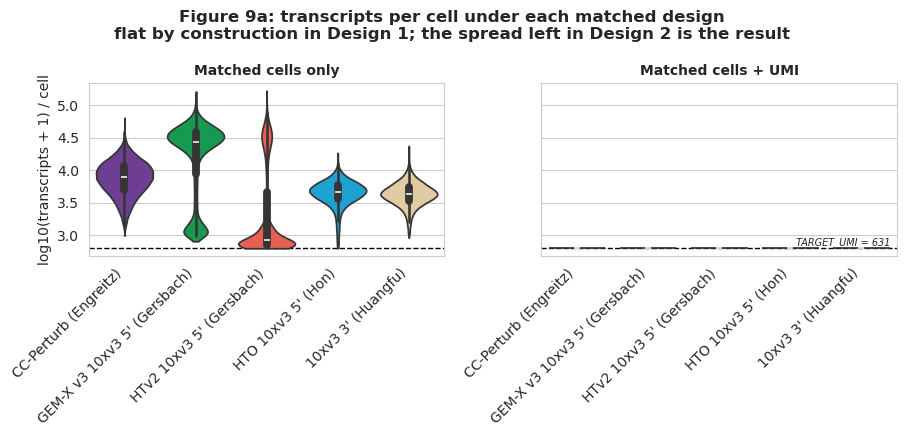

In [29]:
# ---- Figure 9a: did the matching actually work? --------------------------
fig9a, axes = plt.subplots(1, len(CONDITIONS), figsize=(4.6 * len(CONDITIONS), 4.4),
                           sharey=True, squeeze=False)
for ax, cond in zip(axes[0], CONDITIONS):
    sub = ds_cell_df[ds_cell_df["condition"] == cond]
    sns.violinplot(data=sub, x="dataset", y="log10_umi", palette=COLOR_MAP, ax=ax, cut=0,
                   order=DOWNSAMPLE_DATASETS)
    ax.set_title(cond, fontsize=10, fontweight="bold")
    ax.set_xlabel(None)
    ax.tick_params(axis="x", rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
axes[0][0].set_ylabel("log10(transcripts + 1) / cell")
# TARGET_UMI reference on every panel: Design 1 sits exactly on it, so the gap
# between it and the Design 2 violins is the extra depth equal reads bought.
for ax in axes[0]:
    ax.axhline(np.log10(TARGET_UMI + 1), color="black", ls="--", lw=1, zorder=0)
axes[0][-1].text(0.98, np.log10(TARGET_UMI + 1), f" TARGET_UMI = {TARGET_UMI:,}",
                 transform=axes[0][-1].get_yaxis_transform(), ha="right", va="bottom",
                 fontsize=7, style="italic")
fig9a.suptitle("Figure 9a: transcripts per cell under each matched design\n"
               "flat by construction in Design 1; the spread left in Design 2 is the result",
               fontweight="bold")
fig9a.tight_layout()
fig9a.savefig(os.path.join(OUT_DIR, "Q9a_matched_umi_distributions.png"), dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_2397686/1211437885.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="dataset", y="n_genes", palette=COLOR_MAP, ax=ax, cut=0,
/tmp/ipykernel_2397686/1211437885.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="dataset", y="n_genes", palette=COLOR_MAP, ax=ax, cut=0,


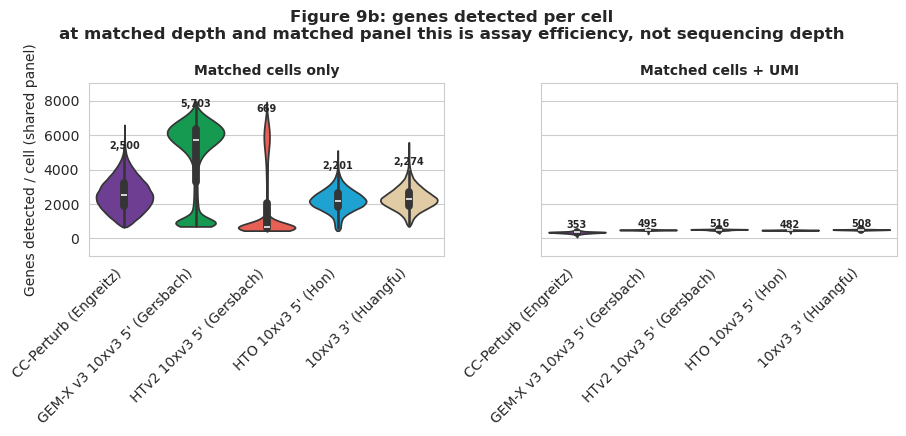

In [30]:
# ---- Figure 9b: genes detected per cell — the headline readout -----------
fig9b, axes = plt.subplots(1, len(CONDITIONS), figsize=(4.6 * len(CONDITIONS), 4.4),
                           sharey=True, squeeze=False)
for ax, cond in zip(axes[0], CONDITIONS):
    sub = ds_cell_df[ds_cell_df["condition"] == cond]
    sns.violinplot(data=sub, x="dataset", y="n_genes", palette=COLOR_MAP, ax=ax, cut=0,
                   order=DOWNSAMPLE_DATASETS)
    med = sub.groupby("dataset")["n_genes"].median().loc[DOWNSAMPLE_DATASETS]
    top = sub.groupby("dataset")["n_genes"].quantile(0.995).loc[DOWNSAMPLE_DATASETS]
    for i, (v, t) in enumerate(zip(med.values, top.values)):
        ax.text(i, t, f"{v:,.0f}", ha="center", va="bottom", fontsize=7, fontweight="bold")
    ax.margins(y=0.14)
    ax.set_title(cond, fontsize=10, fontweight="bold")
    ax.set_xlabel(None)
    ax.tick_params(axis="x", rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
axes[0][0].set_ylabel(f"Genes detected / cell ({'shared panel' if gene_panel else 'full panel'})")
fig9b.suptitle("Figure 9b: genes detected per cell\n"
               "at matched depth and matched panel this is assay efficiency, not sequencing depth",
               fontweight="bold")
fig9b.tight_layout()
fig9b.savefig(os.path.join(OUT_DIR, "Q9b_matched_genes_per_cell.png"), dpi=300, bbox_inches="tight")
plt.show()

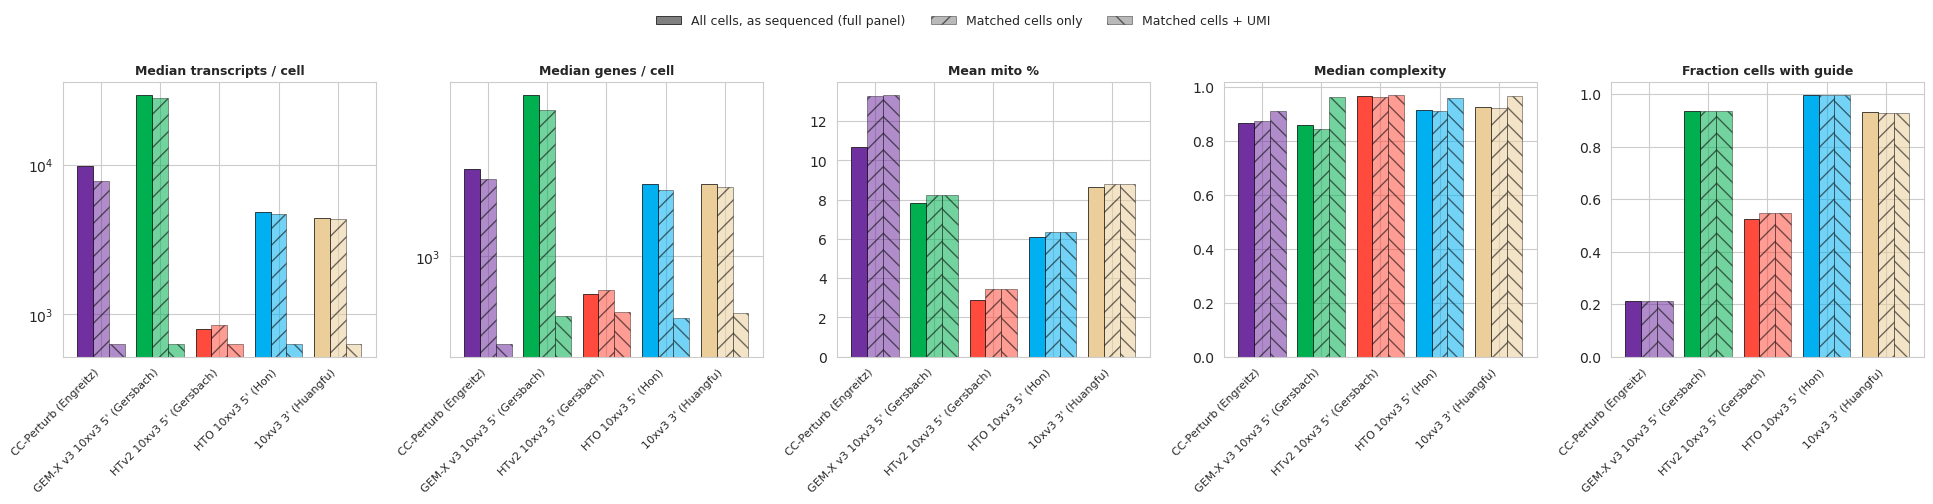

In [31]:
# ---- Figure 9c: QC metrics, as sequenced vs matched ----------------------
BAR_METRICS = [
    ("median_umi",            "Median transcripts / cell"),
    ("median_genes",          "Median genes / cell"),
    ("mean_mito_pct",         "Mean mito %"),
    ("median_complexity",     "Median complexity"),
    ("frac_cells_with_guide", "Fraction cells with guide"),
]
conds_plot = list(downsample_summary.index.get_level_values("condition").unique())

fig9c, axes = plt.subplots(1, len(BAR_METRICS), figsize=(3.9 * len(BAR_METRICS), 4.6))
x = np.arange(len(DOWNSAMPLE_DATASETS))
width = 0.8 / len(conds_plot)
hatches = ["", "//", "\\\\", "xx"]

for ax, (col, label) in zip(axes, BAR_METRICS):
    for k, cond in enumerate(conds_plot):
        vals = downsample_summary.loc[cond, col].reindex(DOWNSAMPLE_DATASETS).values
        ax.bar(x + (k - (len(conds_plot) - 1) / 2) * width, vals, width,
               color=[COLOR_MAP[d] for d in DOWNSAMPLE_DATASETS], edgecolor="black",
               linewidth=0.5, alpha=1.0 if k == 0 else 0.55, hatch=hatches[k % len(hatches)])
    ax.set_xticks(x)
    ax.set_xticklabels(DOWNSAMPLE_DATASETS, rotation=45, ha="right", fontsize=8)
    ax.set_title(label, fontsize=9, fontweight="bold")
    if col in ("median_umi", "median_genes"):
        ax.set_yscale("log")

handles = [plt.Rectangle((0, 0), 1, 1, facecolor="grey", edgecolor="black", linewidth=0.5,
                         alpha=1.0 if k == 0 else 0.55, hatch=hatches[k % len(hatches)], label=cond)
           for k, cond in enumerate(conds_plot)]
fig9c.legend(handles=handles, loc="upper center", ncol=len(conds_plot), frameon=False,
             bbox_to_anchor=(0.5, 1.10), fontsize=9)
fig9c.tight_layout()
fig9c.savefig(os.path.join(OUT_DIR, "Q9c_matched_qc_barplots.png"), dpi=300, bbox_inches="tight")
plt.show()

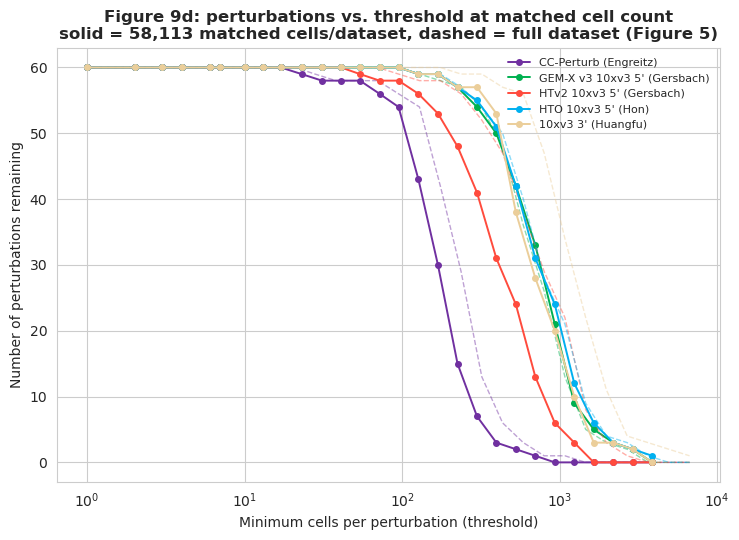

In [32]:
# ---- Figure 9d: perturbations vs cell threshold, at matched cell counts ---
# Guides are never downsampled, so this depends only on the matched cell sample
# and is identical across the two designs. Dashed = the full-dataset Figure 5.
fig9d, ax = plt.subplots(figsize=(7.5, 5.5))
max_seen = max((c.max() for c in ds_tf_counts.values() if len(c) > 0), default=1)
thresholds_ds = np.unique(np.round(np.geomspace(1, max_seen, 30)).astype(int))

for ds in DATASETS:
    name = ds["display_name"]
    if name not in DOWNSAMPLE_DATASETS:
        continue
    counts = ds_tf_counts[name].values
    ax.plot(thresholds_ds, [int((counts >= t).sum()) for t in thresholds_ds],
            marker="o", markersize=4, linewidth=1.4, color=ds["color"], label=name)
    full = tf_counts_by_ds[name].values
    ax.plot(thresholds, [int((full >= t).sum()) for t in thresholds],
            linewidth=1.0, linestyle="--", alpha=0.45, color=ds["color"])

ax.set_xscale("log")
ax.set_xlabel("Minimum cells per perturbation (threshold)")
ax.set_ylabel("Number of perturbations remaining")
ax.set_title(f"Figure 9d: perturbations vs. threshold at matched cell count\n"
             f"solid = {N_CELLS:,} matched cells/dataset, dashed = full dataset (Figure 5)",
             fontweight="bold")
ax.legend(frameon=False, fontsize=8, loc="upper right")
fig9d.tight_layout()
fig9d.savefig(os.path.join(OUT_DIR, "Q9d_matched_perturbations_vs_threshold.png"), dpi=300, bbox_inches="tight")
plt.show()

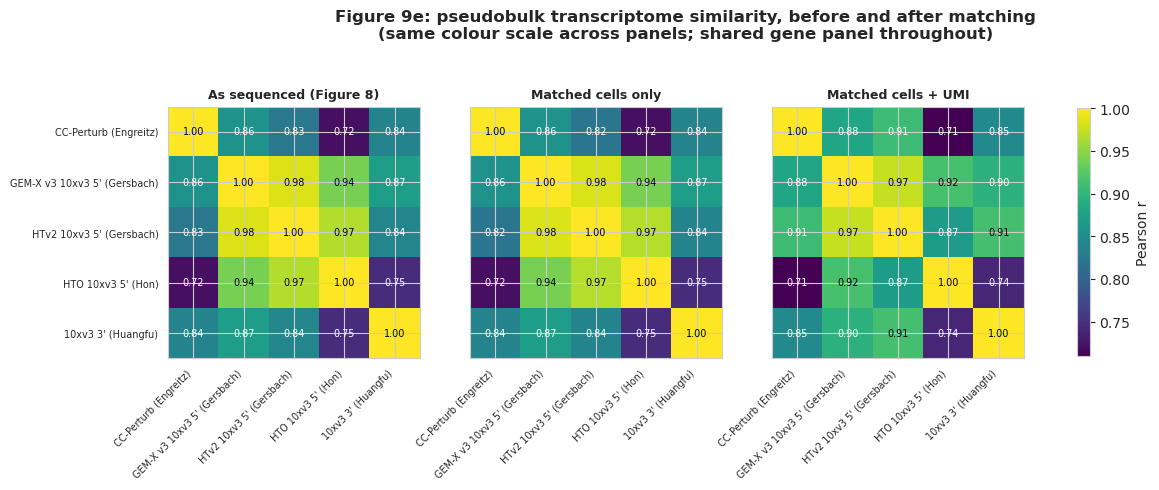

In [33]:
# ---- Figure 9e: pseudobulk similarity, as sequenced vs matched -----------
panel_genes = sorted(set.intersection(*[set(ds_pseudobulk[(CONDITIONS[0], n)].index)
                                        for n in DOWNSAMPLE_DATASETS]))
corr_by_cond = {}
for cond in CONDITIONS:
    pb = pd.DataFrame({n: ds_pseudobulk[(cond, n)].reindex(panel_genes) for n in DOWNSAMPLE_DATASETS})
    corr_by_cond[cond] = np.log2(pb / pb.sum(axis=0) * 1e6 + 1).corr(method="pearson")

panels = [("As sequenced (Figure 8)", corr_pearson.loc[DOWNSAMPLE_DATASETS, DOWNSAMPLE_DATASETS])]
panels += [(c, corr_by_cond[c]) for c in CONDITIONS]

fig9e, axes = plt.subplots(1, len(panels), figsize=(4.6 * len(panels), 4.6))
vmin = min(c.values.min() for _, c in panels)
for ax, (title, corr) in zip(axes, panels):
    c = corr.loc[DOWNSAMPLE_DATASETS, DOWNSAMPLE_DATASETS].values
    im = ax.imshow(c, vmin=vmin, vmax=1.0, cmap="viridis")
    ax.set_xticks(range(len(DOWNSAMPLE_DATASETS)))
    ax.set_xticklabels(DOWNSAMPLE_DATASETS, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(DOWNSAMPLE_DATASETS)))
    # label the y-axis once, otherwise long dataset names run over the panel to the left
    ax.set_yticklabels(DOWNSAMPLE_DATASETS if ax is axes[0] else [], fontsize=7)
    for i in range(len(DOWNSAMPLE_DATASETS)):
        for j in range(len(DOWNSAMPLE_DATASETS)):
            ax.text(j, i, f"{c[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if c[i, j] < vmin + 0.7 * (1 - vmin) else "black")
    ax.set_title(title, fontsize=9, fontweight="bold")
fig9e.colorbar(im, ax=axes, shrink=0.7, label="Pearson r")
fig9e.suptitle("Figure 9e: pseudobulk transcriptome similarity, before and after matching\n"
               "(same colour scale across panels; shared gene panel throughout)",
               fontweight="bold")
fig9e.savefig(os.path.join(OUT_DIR, "Q9e_matched_pseudobulk_correlation.png"), dpi=300, bbox_inches="tight")
plt.show()

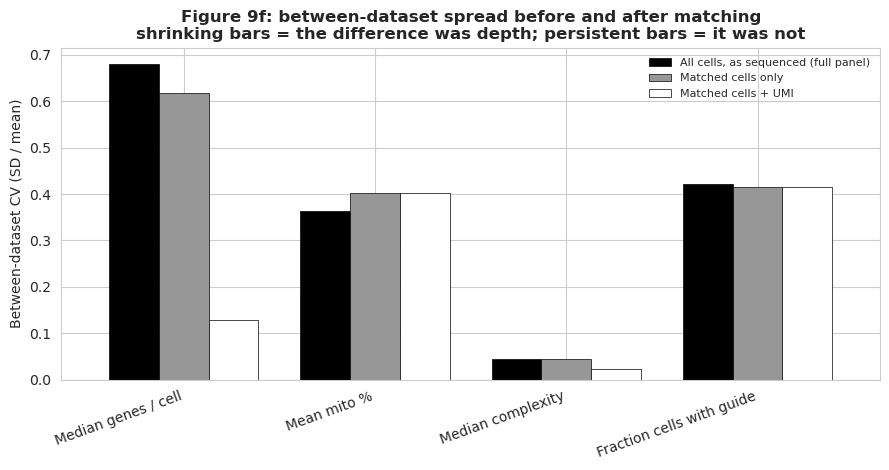

,Median genes / cell,Mean mito %,Median complexity,Fraction cells with guide
"All cells, as sequenced (full panel)",0.682,0.364,0.045,0.422
Matched cells only,0.618,0.403,0.045,0.416
Matched cells + UMI,0.127,0.403,0.023,0.416


In [34]:
# ---- Figure 9f: how much of the raw spread survives matching? ------------
# Coefficient of variation across datasets for each metric, per condition.
# Bars that collapse toward zero were depth artefacts; bars that stay up are
# differences matching could not explain away. This is the by-construction
# counterpart to `frac_between_dataset_var_explained` in Figure 6c.
SPREAD_METRICS = [("median_genes", "Median genes / cell"),
                  ("mean_mito_pct", "Mean mito %"),
                  ("median_complexity", "Median complexity"),
                  ("frac_cells_with_guide", "Fraction cells with guide")]

spread = pd.DataFrame(
    {label: {cond: (downsample_summary.loc[cond, col].std(ddof=0)
                    / abs(downsample_summary.loc[cond, col].mean()))
             for cond in downsample_summary.index.get_level_values("condition").unique()}
     for col, label in SPREAD_METRICS}
)

fig9f, ax = plt.subplots(figsize=(9, 4.8))
spread.T.plot.bar(ax=ax, edgecolor="black", linewidth=0.5, width=0.78, colormap="Greys_r")
ax.set_ylabel("Between-dataset CV (SD / mean)")
ax.set_xlabel(None)
ax.tick_params(axis="x", rotation=20)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
ax.set_title("Figure 9f: between-dataset spread before and after matching\n"
             "shrinking bars = the difference was depth; persistent bars = it was not",
             fontweight="bold")
ax.legend(frameon=False, fontsize=8, title=None)
fig9f.tight_layout()
fig9f.savefig(os.path.join(OUT_DIR, "Q9f_spread_before_after_matching.png"), dpi=300, bbox_inches="tight")
plt.show()

spread.round(3)

### Figure 9 outputs

`Q9a_matched_umi_distributions.png`, `Q9b_matched_genes_per_cell.png`, `Q9c_matched_qc_barplots.png`, `Q9d_matched_perturbations_vs_threshold.png`, `Q9e_matched_pseudobulk_correlation.png`, `Q9f_spread_before_after_matching.png`, all in `OUT_DIR` alongside Q1-Q8.

**How to read this section.** Figure 9a is the control - Design 1's violins should collapse onto a single value, confirming the matching did what it claims, while Design 2's remaining spread *is* the result (equal reads in, unequal transcripts out). Figure 9b is the main readout: genes recovered per cell at identical depth and identical gene panel. Figure 9f is the one-number summary, and is the by-construction analogue of `frac_between_dataset_var_explained` in Figure 6c - a metric whose between-dataset CV collapses from "as sequenced" to "matched" was measuring sequencing depth; one that stays high is measuring something matching cannot explain away.

**Two knobs worth trying before drawing conclusions**, both in the Figure 9 config cell:
- `DOWNSAMPLE_DATASETS` - dropping the shallowest dataset raises `TARGET_UMI` for everyone else, often a lot. Worth running both ways, since the all-5 target is set by the shallowest library and can be very shallow.
- `UMI_QUANTILE` / `TARGET_UMI_OVERRIDE` - trades target depth against how many cells stay eligible. Design table reports both sides of that trade.

All figures are also saved as PNGs to `OUT_DIR`:
```
/hpc/group/gersbachlab/seg95/tf_perturb_seq/src/tf_perturb_seq/gene_program_discovery/benchmark_figures_qc
```

Figures 6–7 add: `Q6a_depth_vs_complexity_landscape.png`, `Q6b_dataset_depth_complexity_summary.png`, `Q6c_depth_complexity_adjusted_barplots.png`, and one `Q7_per_library_<dataset>.png` per dataset that has a resolvable library/batch column with more than one distinct value.

Figure 8 adds: `Q8a_pseudobulk_correlation_heatmap.png`, `Q8b_pseudobulk_dendrogram.png`, and `Q8c_pseudobulk_pairwise_scatter.png`.

Figure 9 adds: `Q9a_matched_umi_distributions.png`, `Q9b_matched_genes_per_cell.png`, `Q9c_matched_qc_barplots.png`, `Q9d_matched_perturbations_vs_threshold.png`, `Q9e_matched_pseudobulk_correlation.png`, `Q9f_spread_before_after_matching.png`.